# Предсказание температуры стали

### Цель работы
Чтобы оптимизировать производственные расходы, металлургический комбинат решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. **Необходимо построить модель, которая будет предсказывать температуру сплава.**

### Описание данных
Данные хранятся в *Sqlite*, которая состоит из нескольких таблиц:
* `steel.data_arc` — данные об электродах;
* `steel.data_bulk` — данные об объёме сыпучих материалов;
* `steel.data_bulk_time` — данные о времени подачи сыпучих материалов;
* `steel.data_gas` — данные о продувке сплава газом;
* `steel.data_temp` — данные об измерениях температуры;
* `steel.data_wire` — данные об объёме проволочных материалов;
* `steel.data_wire_time` — данные о времени подачи проволочных материалов.

**Таблица `steel.data_arc`**
* `key` — номер партии;
* `BeginHeat` — время начала нагрева;
* `EndHeat` — время окончания нагрева;
* `ActivePower` — значение активной мощности;
* `ReactivePower` — значение реактивной мощности.

**Таблица `steel.data_bulk`**
* `key` — номер партии;
* `Bulk1` … `Bulk15` — объём подаваемого материала.

**Таблица `steel.data_bulk_time`**
* `key` — номер партии;
* `Bulk1 … Bulk15` — время подачи материала.

**Таблица `steel.data_gas`**
* `key` — номер партии;
* `gas` — объём подаваемого газа.

**Таблица `steel.data_temp`**
* `key` — номер партии;
* `MesaureTime` — время замера;
* `Temperature` — значение температуры.

**Таблица `steel.data_wire`**
* `key` — номер партии;
* `Wire1 … Wire9` — объём подаваемых проволочных материалов.

**Таблица `steel.data_wire_time`**
* `key` — номер партии;
* `Wire1 … Wire9` — время подачи проволочных материалов.

### План работы

1. Загрузка данных
2. Исследовательский анализ и предобработка данных
3. Обучение модели
4. Тестирование модели
5. Выводы

## Загрузка данных

Импортируем необходимые для работы библиотеки.

In [1]:
!pip install phik -q
!pip install shap -q

In [2]:
import os
import pandas as pd
from sqlalchemy import create_engine

import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from phik import phik_matrix
from sklearn.model_selection import train_test_split,  RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import random
import torch
import torch.nn as nn
import shap

In [3]:
# Задаем константу 
RANDOM_STATE = 200726
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)

Подключимся к базе данных.

In [4]:
# Путь к файлу 
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False) 

Для осмотра таблиц используем sql-запрос, загружаем данные в DataFrame.

In [5]:
data_arc = '''
SELECT *
FROM data_arc
'''

data_bulk = '''
SELECT *
FROM data_bulk
'''

data_bulk_time = '''
SELECT *
FROM data_bulk_time
'''

data_gas = '''
SELECT *
FROM data_gas
'''

data_temp = '''
SELECT *
FROM data_temp
'''

data_wire = '''
SELECT *
FROM data_wire
'''

data_wire_time = '''
SELECT *
FROM data_wire_time
'''

In [6]:
# Загружаем данные в DataFrame
df_arc = pd.read_sql_query(data_arc, con=engine)
df_bulk = pd.read_sql_query(data_bulk, con=engine)
df_bulk_time = pd.read_sql_query(data_bulk_time, con=engine)
df_gas = pd.read_sql_query(data_gas, con=engine)
df_temp = pd.read_sql_query(data_temp, con=engine)
df_wire = pd.read_sql_query(data_wire, con=engine)
df_wire_time = pd.read_sql_query(data_wire_time, con=engine)

Посмотрим на исходные данные, нужно проверить все ли таблицы содержат данные.

In [7]:
# Функция для вывода общей информации и первых n строк датафрейма
def display_info(data, n = 5):
    data.info()
    print('-' * 40)
    display(data.head(n))
    print('-' * 100)

**Таблица `df_arc`**

In [8]:
display_info(df_arc)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB
----------------------------------------


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


----------------------------------------------------------------------------------------------------


В `df_arc` содержатся данные об электродах: начало и конец нагрева дугой, активная и реактивная мощность. Всего 14867 строк и 5 колонок, пропущенных значений нет. Видно, что нагрев для одной партии может происходить и `key` (номер партии) может дублироваться.

Названия колонок частично отличаются от заявленных в описании данных, их нужно будет привести к общему виду. Также тип данных для колонок, где указаны начало и конец нагрева, неподходящий.    

**Таблица `df_bulk`**

In [9]:
display_info(df_bulk)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     object 
 6   Bulk 6   576 non-null    object 
 7   Bulk 7   25 non-null     object 
 8   Bulk 8   1 non-null      object 
 9   Bulk 9   19 non-null     object 
 10  Bulk 10  176 non-null    object 
 11  Bulk 11  177 non-null    object 
 12  Bulk 12  2450 non-null   object 
 13  Bulk 13  18 non-null     object 
 14  Bulk 14  2806 non-null   object 
 15  Bulk 15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB
----------------------------------------


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,NaN,NaN,NaN,81.0,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,NaN,NaN,NaN,78.0,None,None,None,None,None,None,None,203.0,None,151.0,152.0


----------------------------------------------------------------------------------------------------


В `df_bulk` содержатся данные об объеме сыпучих материалов, всего 3129 строк и 16 колонок. Видно, что в таблице много пропусков и тип данных для столбцов, которые содержат информацию об объеме, разный: часть данных типа `float`, часть `object`.   

**Таблица `df_bulk_time`**

In [10]:
display_info(df_bulk_time)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB
----------------------------------------


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


----------------------------------------------------------------------------------------------------


В `df_bulk_time` содержатся данные о времени подачи сыпучих материалов. В датафрейме также 3129 строк, 16 колонок, много пропусков. Тип данных для времени также нужно будет изменить.

**Таблица `df_gas`**

In [11]:
display_info(df_gas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB
----------------------------------------


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


----------------------------------------------------------------------------------------------------


`df_gas` содержит информация об продувке материала газом, а именно объем подаваемого газа. Здесь только 2 колонки и 3239 строк, пропусков нет, однако названия второй колонки нужно будет исправить. 

**Таблица `df_temp`**

In [12]:
display_info(df_temp)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   Время замера  18092 non-null  object
 2   Температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB
----------------------------------------


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


----------------------------------------------------------------------------------------------------


В `df_temp` содержится информация о времени и результатах замера температуры. 3 колонки, 18092 строки. Есть пропуски и неподходящий тип данных.

**Таблица `df_wire`**

In [13]:
display_info(df_wire)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   object 
 3   Wire 3  63 non-null     object 
 4   Wire 4  14 non-null     object 
 5   Wire 5  1 non-null      object 
 6   Wire 6  73 non-null     object 
 7   Wire 7  11 non-null     object 
 8   Wire 8  19 non-null     object 
 9   Wire 9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB
----------------------------------------


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None
3,4,89.063515,None,None,None,None,None,None,None,None
4,5,89.238236,9.11456,None,None,None,None,None,None,None


----------------------------------------------------------------------------------------------------


В таблице `df_wire` содержатся данные об объеме подаваемых проволочных материалов. 2081 строка и 10 колонок. В данных много пропусков, используется разный и чаще неподходящий тип данных для одинаковых по смысловому содержанию колонок.

**Таблица `df_wire_time`**

In [14]:
display_info(df_wire_time)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB
----------------------------------------


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None


----------------------------------------------------------------------------------------------------


`df_wire_time` содержит данные о времени подаваемых проволочных материалов. 3081 строка и 10 колонок. Также видно, что много пропусков и используется неподходящий тип даных для колонок, где хранится информация о времени.

**В результате, данные загружены, количество таблиц соответствует условию задачи и все таблицы содержат данные.** Однако при первичном осмотре видны следующий проблемы:
* неудобные и неоднородные названия колонок в таблицах;
* пропуски в данных;
* неверные типы данных.

Необходимо подробно исследовать каждую таблицу и подготовить данные. 

## Исследовательский анализ и предобработка данных

### Таблица `df_arc`

Для наглядности еще раз выведем основную информацию и первые строки датафрейма.

In [15]:
display_info(df_arc, n=3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB
----------------------------------------


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


----------------------------------------------------------------------------------------------------


**Переименование колонок**

Поскольку большой часть колонок в датафрейме имеет названия на русском языке, для удобства работы сначала переименуем их. 

In [16]:
df_arc = df_arc.rename(columns={'Начало нагрева дугой': 'begin_heat',
                       'Конец нагрева дугой': 'end_heat', 
                       'Активная мощность': 'active_power',
                       'Реактивная мощность': 'reactive_power'})
df_arc.columns

Index(['key', 'begin_heat', 'end_heat', 'active_power', 'reactive_power'], dtype='object')

**Контроль пропусков и дубликатов**

Для проверки качества и целостности данныx будем пользоваться функцией `check_missing_and_duplicates`. Поскольку номер партии может выступать в роли уникального индефикатора, допольнительно проверим количество уникальных значений в колонке `key`.

In [17]:
# Функция для вывода пропусков и дубликатов 
def check_missing_and_duplicates(data):
    print(f"Количество строк: {len(data)}")

    # Пропуски
    mis_count = data.isna().sum().sum()
    print(f"\nКоличество пропусков во всем датафрейме: {mis_count}")
    if mis_count > 0:
        print("Количество пропусков по столбцам:")
        print(data.isna().sum())

    # Явные дубликаты
    dup_count = data.duplicated().sum()
    print(f"\nКоличество явных дубликатов: {dup_count}")
    if dup_count > 0:
        print("Примеры дублирующихся строк:")
        print(data[data.duplicated()].head())

    # Уникальные значения key
    print(f"\nКоличество уникальных значений в столбце 'key': {data['key'].nunique()}")

In [18]:
check_missing_and_duplicates(df_arc)

Количество строк: 14876

Количество пропусков во всем датафрейме: 0

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3214


Как уже отмечалось ранее, пропусков в датафрейме нет. Также отсутствуют явные дубликаты. Количество уникальных партий (по колонке `key`) - 3214.

**Преобразование типов данных**

Приведем колонки `begin_heat` и 'end_heat` из типа `object` к типу данных *время* (*datatime*).

In [19]:
df_arc['begin_heat'] = pd.to_datetime(df_arc['begin_heat'], format='%Y-%m-%d %H:%M:%S')
df_arc['end_heat']   = pd.to_datetime(df_arc['end_heat'],   format='%Y-%m-%d %H:%M:%S')
# Проверка типов данных
df_arc.dtypes

key                        int64
begin_heat        datetime64[ns]
end_heat          datetime64[ns]
active_power             float64
reactive_power           float64
dtype: object

**Исследовательский анализ данных**

Для изучения структуры данных выведем базовую статистику по столбцам и изучим распределение признаков с помощью графиков, чтобы выявить особенности данных, возможные выбросы и характер распределения.

In [20]:
df_arc.describe()

,key,begin_heat,end_heat,active_power,reactive_power
count,14876.000000,14876,14876,14876.000000,14876.000000
mean,1615.220422,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,1.000000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,806.000000,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,1617.000000,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2429.000000,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,3241.000000,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,934.571502,NaN,NaN,0.258885,5.873485


В таблице содержатся данные о нагреве электродов с 3 мая по 6 сентября включительно. Для количественных признаков - активной и реактивной мощности - построим диаграмму размаха и гистограму.

In [21]:
# Функция для построения гистограммы и диаграммы размаха для количественных признаков
def hist_and_boxplot(x, df, bins):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=x, bins=bins, kde=True)
    plt.title('Гистограмма')
    plt.subplot(1, 2, 2) 
    df.boxplot(column=x)
    plt.title('Boxplot')
    plt.suptitle(f' Гистограмма и диаграмма размаха для {x}', fontsize=15)
    plt.show()

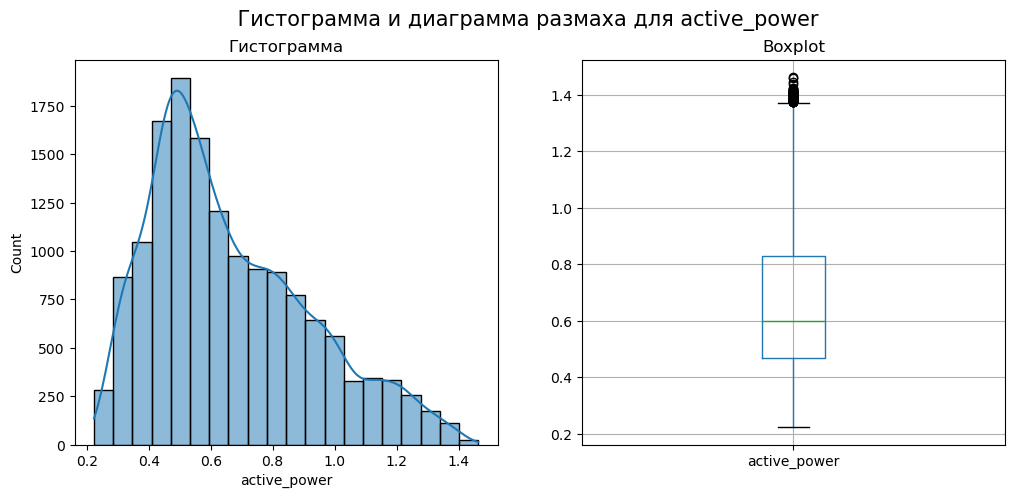

In [22]:
hist_and_boxplot('active_power', df_arc, bins=20)

Активная мощность варьируется от ~ 0.22 до 1.45 условных единиц, среднее значение примерно около 0.66 у.е. Распределение со смещением вправо, но аномальных значений нет. 

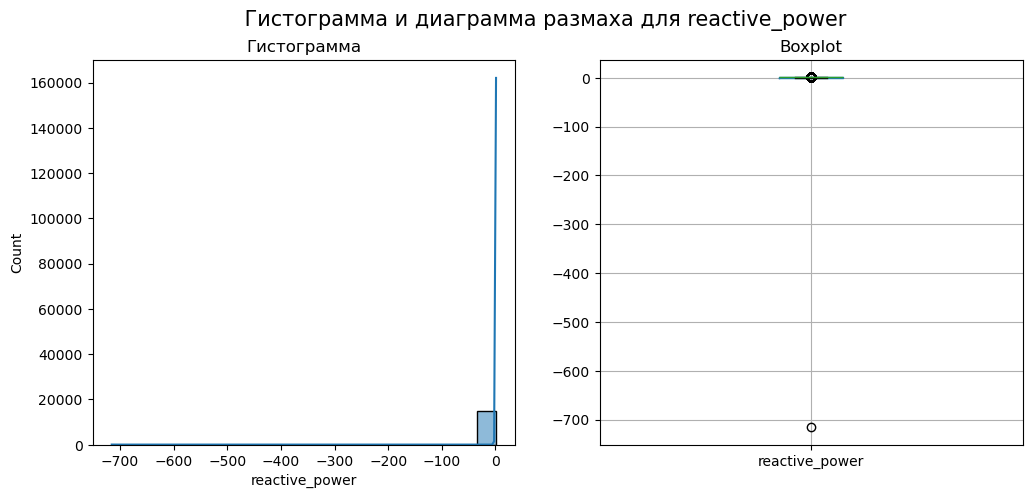

In [23]:
hist_and_boxplot('reactive_power', df_arc, bins=20)

Видно, что у реактивной мощности есть аномальные значения - отрицательные мощности, около -700 единиц. Заменим эти аномалии на медианное значение.

In [24]:
median_value = df_arc.loc[df_arc['reactive_power'] > 0, 'reactive_power'].median()
df_arc.loc[df_arc['reactive_power'] < 0, 'reactive_power'] = median_value 

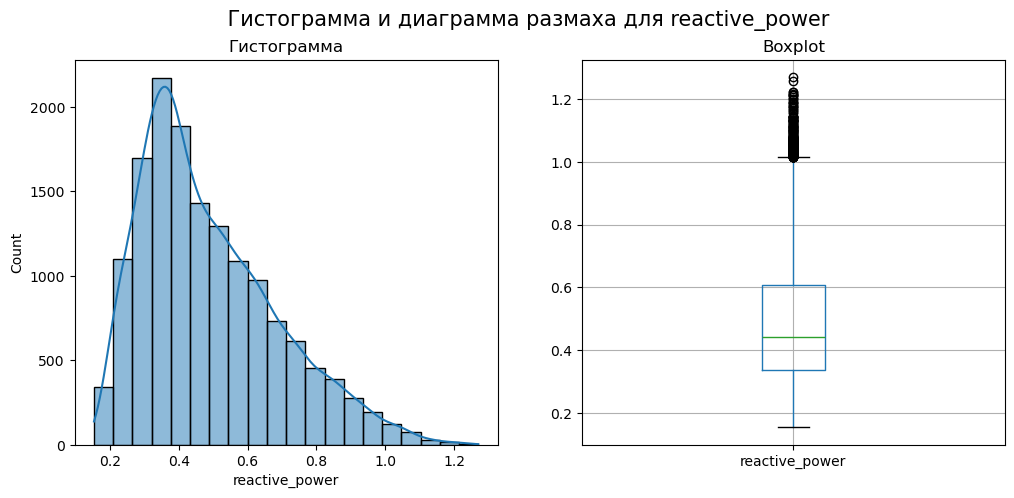

In [25]:
hist_and_boxplot('reactive_power', df_arc, bins=20)

Теперь распределение реактивной мощности схоже с распределением активной мощности: средняя мощность ~0.44, а максимальные значения достигают порядка 1.25 единиц. 

**Генерация новых признаков**

Необходимо сгенерировать новые признаки, которые могут пригодиться при обучении. Сначала найдем  длительность нагрева, общую мощность, соотношение активной мощности к реактивной и энергию для каждого запуска.

In [26]:
# Длительность нагрева
df_arc['time_heat'] = (df_arc['end_heat'] - df_arc['begin_heat']).dt.total_seconds()
df_arc['time_heat'] = df_arc['time_heat'].astype(int)

# Общая мощность
df_arc['total_power'] = ((df_arc['active_power'])**2 + (df_arc['reactive_power'])**2)**0.5  

# Соотношение мощностей
df_arc['ratio_power'] = df_arc['active_power']/df_arc['reactive_power']

# Энергия 
df_arc['energy'] = df_arc['total_power'] * df_arc['time_heat']

Теперь сгенерируем следующие признаки для каждой партии: 
* количество запусков нагрева электродами `heat_count`;
* суммарное время нагрева электродов `heat_time`;
* среднее значение полной мощности `mean_total_power`;
* среднее отношение мощностей (активной к реактивной)  `mean_ratio_power`;
* суммарная энергия на нагрев `total_energy`.

In [27]:
agg_df_arc = df_arc.groupby('key', sort=False).agg(
            heat_count=('key', 'size'),                     # число запусков нагрева электродами
            heat_time=('time_heat', 'sum'),                 # суммарное время на нагрев электродов
            mean_total_power=('total_power', 'mean'),       # средняя полная мощность
            mean_ratio_power=('ratio_power', 'mean'),       # среднее отношение мощностей
            total_energy=('energy', 'sum')                  # суммарная энергия
).reset_index() 

In [28]:
display_info(agg_df_arc)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   key               3214 non-null   int64  
 1   heat_count        3214 non-null   int64  
 2   heat_time         3214 non-null   int32  
 3   mean_total_power  3214 non-null   float64
 4   mean_ratio_power  3214 non-null   float64
 5   total_energy      3214 non-null   float64
dtypes: float64(3), int32(1), int64(2)
memory usage: 138.2 KB
----------------------------------------


,key,heat_count,heat_time,mean_total_power,mean_ratio_power,total_energy
0,1,5,1098,0.743747,1.421570,770.282114
1,2,4,811,0.647087,1.479201,481.760005
2,3,5,655,1.003845,1.396069,722.837668
3,4,4,741,0.850010,1.307446,683.455597
4,5,4,869,0.704245,1.328894,512.169934


----------------------------------------------------------------------------------------------------


Таким образом, в `agg_df_arc` содержатся агрегированные признаки о нагреве электродов для каждой партии стали. Изучим их распределения после объединения этого датафрейма с другими таблицами. 

### Таблица `df_bulk`

In [29]:
display_info(df_bulk, n=3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     object 
 6   Bulk 6   576 non-null    object 
 7   Bulk 7   25 non-null     object 
 8   Bulk 8   1 non-null      object 
 9   Bulk 9   19 non-null     object 
 10  Bulk 10  176 non-null    object 
 11  Bulk 11  177 non-null    object 
 12  Bulk 12  2450 non-null   object 
 13  Bulk 13  18 non-null     object 
 14  Bulk 14  2806 non-null   object 
 15  Bulk 15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB
----------------------------------------


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0


----------------------------------------------------------------------------------------------------


**Переименование колонок**

Приведем названия всех столбцов датафрейма к формату *snake_case*, это упростит работу с данными.

In [30]:
df_bulk.columns = df_bulk.columns.str.lower().str.replace(' ', '_', regex=False)
df_bulk.columns

Index(['key', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')

**Контроль пропусков и дубликатов**

In [31]:
check_missing_and_duplicates(df_bulk)

Количество строк: 3129

Количество пропусков во всем датафрейме: 35776
Количество пропусков по столбцам:
key           0
bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3129


Количество уникальных партий совпадает с количеством строк в датафрейме, т.е. каждая строка соответствует отдельной партии.

Пропуск в данных означает, что материал не добавляли в партию. Поэтому заменим пропуски на нули.

In [32]:
df_bulk = df_bulk.fillna(0)

print(f"Количество пропусков после преобразований: {df_bulk.isna().sum().sum()}")

Количество пропусков после преобразований: 0


**Преобразование типов данных**

В некоторых колонках с данными об объеме подаваемого материала установлен тип `object`, его следует привести к типу `float`.  

In [33]:
int_cols = [f'bulk_{i}' for i in range(5, 16)]
df_bulk[int_cols] = df_bulk[int_cols].astype('float64')
# Проверка типов данных
df_arc.dtypes

key                        int64
begin_heat        datetime64[ns]
end_heat          datetime64[ns]
active_power             float64
reactive_power           float64
time_heat                  int32
total_power              float64
ratio_power              float64
energy                   float64
dtype: object

**Исследовательский анализ данных**

In [34]:
# Базовая статистика
df_bulk.describe()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
count,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000
mean,1624.383509,3.160435,1.779163,47.240332,33.830617,2.633749,21.892298,2.441675,0.015660,0.463407,4.684564,4.345478,203.948226,1.041866,152.706616,115.319271
std,933.337642,11.869164,21.217878,74.239954,56.034505,20.918138,55.492582,31.944063,0.875978,6.154398,20.157323,22.699580,151.419639,14.114252,81.091421,84.488698
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,816.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,105.000000,0.000000,104.000000,0.000000
50%,1622.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,0.000000,148.000000,106.000000
75%,2431.000000,0.000000,0.000000,80.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,263.000000,0.000000,202.000000,204.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.000000,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


Ожидаемо, минимальное значение объема сыпучих материалов равно 0. Медиана для большинства колонок тоже ноль, это следствие большой доли нулевых значений (т.е. случаев когда подачи материала не было). При это разброс максимальных значение существенный - от десятков до тысяч условных единиц.

Посмотрим общее распределение всех подаваемых сыпучих материалов, но без учета нулевых объемов.

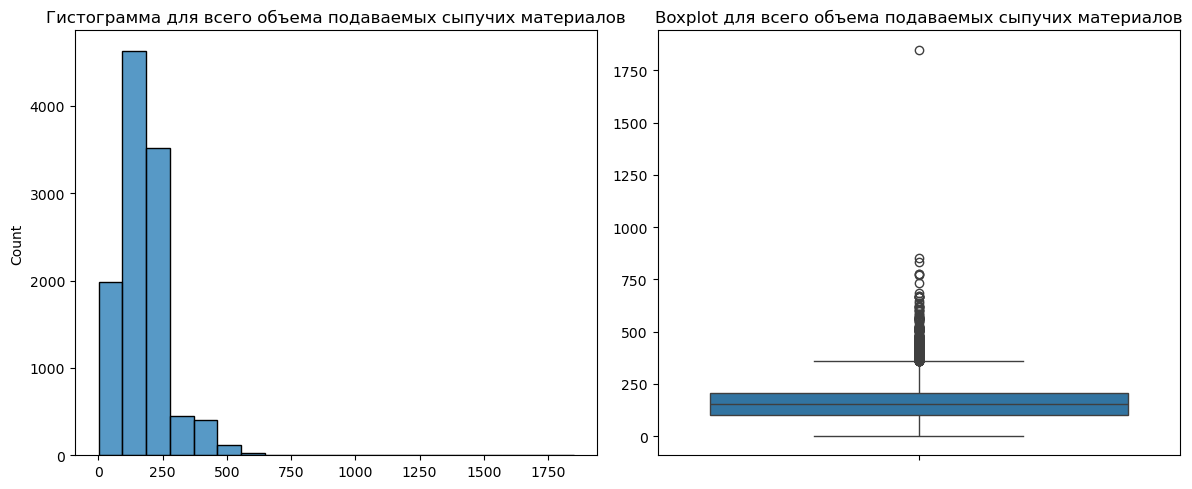

In [35]:
bulk_cols = [f'bulk_{i}' for i in range(1, 16)]
bulk_all = df_bulk[bulk_cols].replace(0, np.nan).stack().dropna()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(bulk_all, bins=20)
plt.title("Гистограмма для всего объема подаваемых сыпучих материалов")
plt.subplot(1, 2, 2)
sns.boxplot(bulk_all)
plt.title("Boxplot для всего объема подаваемых сыпучих материалов")
plt.tight_layout()
plt.show()

Видно, что объем подаваемых сыпучих материалов в среднем составляет около 200 у.е., но в отдельных случаях может достигать 1000 единиц. При этом одно значение сильно выбивается из общей картины — оно превышает 1800 у.е. 

Поскольку нас интересует влияние объема сыпучих материалов на конечную температуру, введем новый признак - суммарный объем подаваемых материалов для каждой партии. Распределение этого признака также изучим после объединения с остальными данными.   

In [36]:
df_bulk['bulk_sum'] = df_bulk[bulk_cols].sum(axis=1)
# Оставляем для каждой партии только суммарный объем
df_bulk_new = df_bulk[['key', 'bulk_sum']].copy()

### Таблица `df_bulk_time`


In [37]:
display_info(df_bulk_time, n=3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB
----------------------------------------


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16


----------------------------------------------------------------------------------------------------


**Переименование колонок**

In [38]:
df_bulk_time.columns = df_bulk_time.columns.str.lower().str.replace(' ', '_', regex=False)
df_bulk_time.columns

Index(['key', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')

**Контроль пропусков и дубликатов** 

In [39]:
check_missing_and_duplicates(df_bulk_time)

Количество строк: 3129

Количество пропусков во всем датафрейме: 35776
Количество пропусков по столбцам:
key           0
bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3129


**Преобразование типов данных**

In [40]:
date_cols = [f'bulk_{i}' for i in range(1, 16)]

for col in date_cols:
    df_bulk_time[col] = pd.to_datetime(df_bulk_time[col], errors='coerce')

# Проверка типов данных
df_arc.dtypes

key                        int64
begin_heat        datetime64[ns]
end_heat          datetime64[ns]
active_power             float64
reactive_power           float64
time_heat                  int32
total_power              float64
ratio_power              float64
energy                   float64
dtype: object

**Исследовательский анализ данных**

In [41]:
df_bulk_time.describe()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
count,3129.000000,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,1624.383509,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,1.000000,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,816.000000,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,1622.000000,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2431.000000,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,3241.000000,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15
std,933.337642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Проверим, что длительность подачи сыпучих материалов не измеряется сутками: для каждой партии рассчитаем интервал между первой и последней подачей. 

Также зафиксируем время последней подачи - оно понадобится, чтобы убедиться, что последний замер температуры был выполнен уже после завершения подачи материалов.

In [42]:
diff = df_bulk_time[date_cols].max(axis=1)-df_bulk_time[date_cols].min(axis=1)
# Интервал подачи материалов в секундах
df_bulk_time['bulk_time'] = diff.dt.total_seconds() 
df_bulk_time['bulk_time'] = df_bulk_time['bulk_time'].astype(int)
# Интервал подачи материалов в часах (для графика)
df_bulk_time['bulk_hours'] = df_bulk_time['bulk_time'] / 3600

# Время последней подачи материала
df_bulk_time['bulk_last_time'] = df_bulk_time[date_cols].max(axis=1)

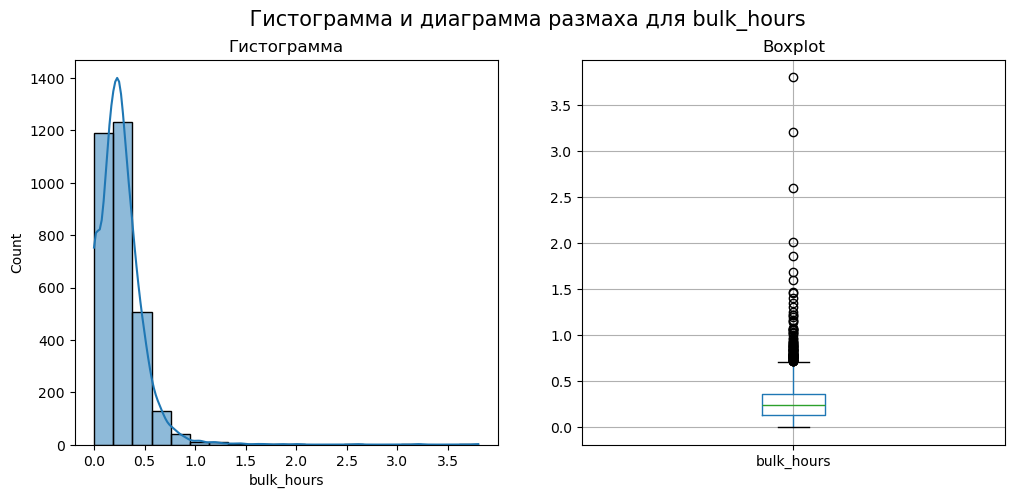

In [43]:
hist_and_boxplot('bulk_hours', df_bulk_time, bins=20)

Распределение длительности подачи сыпучих материалов похоже на распределение Пуассона: преобладают короткие интервалы (до 30 минут), но при этом встречаются и более продолжительные - до нескольких часов.

Отсутствие аномально больших значений (24 часа и больше) говорит о том, что в данных нет явных ошибок измерения.

In [44]:
df_bulk_time_new = df_bulk_time[['key', 'bulk_time', 'bulk_last_time']].copy()

### Таблица `df_gas`

In [45]:
display_info(df_gas, n=3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB
----------------------------------------


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793


----------------------------------------------------------------------------------------------------


**Переименование колонок**

Для удобства сначала переименуем колонку с данными об объеме подаваемого газа. 

In [46]:
df_gas = df_gas.rename(columns={'Газ 1': 'gas'})

df_gas.columns

Index(['key', 'gas'], dtype='object')

**Контроль пропусков и дубликатов** 

In [47]:
check_missing_and_duplicates(df_gas)

Количество строк: 3239

Количество пропусков во всем датафрейме: 0

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3239


Пропуски и явные дубликаты отсутсвуют. Количество уникальных партий совпадает с количеством строк в датафрейме.

Преобразование типов данных не требуется. 

**Исследовательский анализ данных**

In [48]:
df_gas.describe()

,key,gas
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


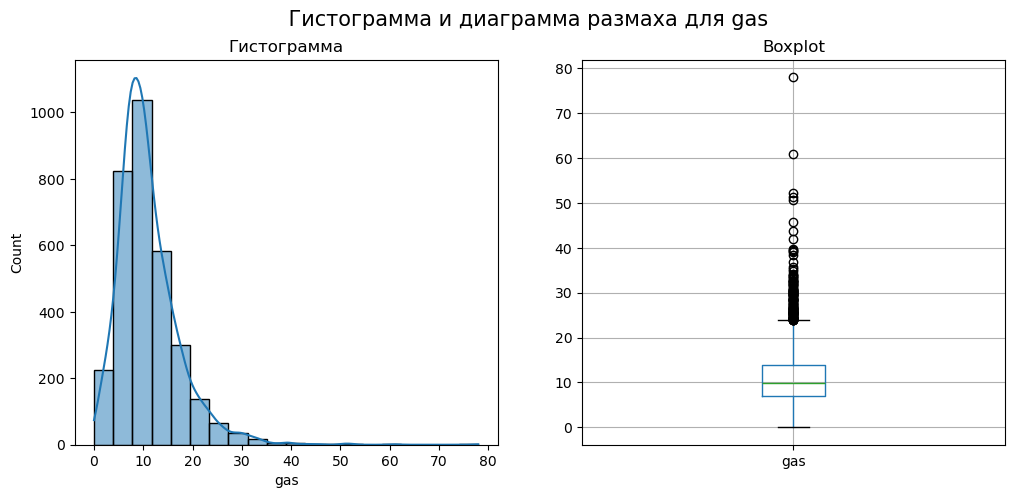

In [49]:
hist_and_boxplot('gas', df_gas, bins=20)

Объем подаваемого газа варьируется в диапазоне ~ от 0 до 80 условных единиц. Распределение значений имеет сдвиг вправо:  большинство наблюдений концентрируется в районе до 20 единиц, среднее значение около 10 единиц, медиана - 11. 

Есть выбросы, но они не являются аномальными.

### Таблица `df_temp`

In [50]:
display_info(df_temp, n = 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   Время замера  18092 non-null  object
 2   Температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB
----------------------------------------


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


----------------------------------------------------------------------------------------------------


Необходимо привести названия второй и третьей колонок к общепринятому виду и изменить тип данных для них. 

**Переименование колонок**

In [51]:
df_temp = df_temp.rename(columns={'Время замера': 'measure_time',
                                  'Температура': 'temperature'})
df_temp.columns

Index(['key', 'measure_time', 'temperature'], dtype='object')

**Контроль пропусков и дубликатов** 

In [52]:
check_missing_and_duplicates(df_temp)

Количество строк: 18092

Количество пропусков во всем датафрейме: 3427
Количество пропусков по столбцам:
key                0
measure_time       0
temperature     3427
dtype: int64

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3216


В `df_temp` большое  количество пропусков в колонке `temperature`. Возможно, из технического сбоя температура не была зафиксирована или данные были потеряны при переносе.  

**Преобразование типов данных**

In [53]:
df_temp['measure_time'] = pd.to_datetime(df_temp['measure_time'], format='%Y-%m-%d %H:%M:%S')
df_temp['temperature'] = df_temp['temperature'].astype('float64')

# Проверка типов данных
df_temp.dtypes

key                      int64
measure_time    datetime64[ns]
temperature            float64
dtype: object

**Исследовательский анализ данных**

In [54]:
df_temp.describe()

,key,measure_time,temperature
count,18092.000000,18092,14665.000000
mean,1616.460977,2019-07-05 13:36:58.791620608,1590.722741
min,1.000000,2019-05-03 11:02:04,1191.000000
25%,807.750000,2019-06-04 00:35:01.249999872,1580.000000
50%,1618.000000,2019-07-03 02:11:48,1590.000000
75%,2429.000000,2019-08-07 23:10:05.249999872,1599.000000
max,3241.000000,2019-09-06 17:30:05,1705.000000
std,934.641385,NaN,20.394381


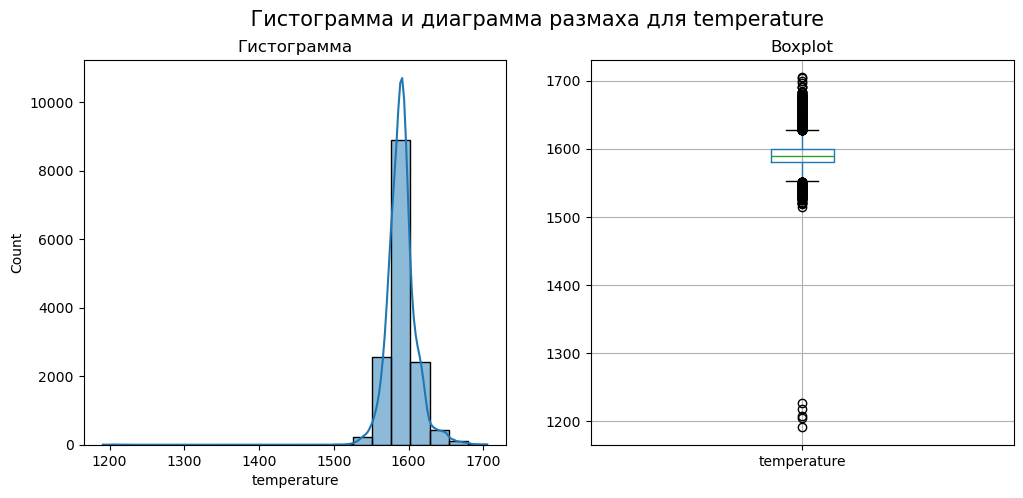

In [55]:
hist_and_boxplot('temperature', df_temp, bins=20)

На графиках видно, что в данных есть значения температуры, которые заметно отличаются от других (около 1200 градусов). Однако заказчик предупредил, что значения температуры ниже 1500 градусов - аномальные. Заменим эти экстремально низкие значения температуры на минимально допустимую температуру в данных. 

In [56]:
min_value = df_temp.loc[df_temp['temperature'] > 1500, 'temperature'].min()
df_temp.loc[df_temp['temperature'] < 1500, 'temperature'] = min_value 

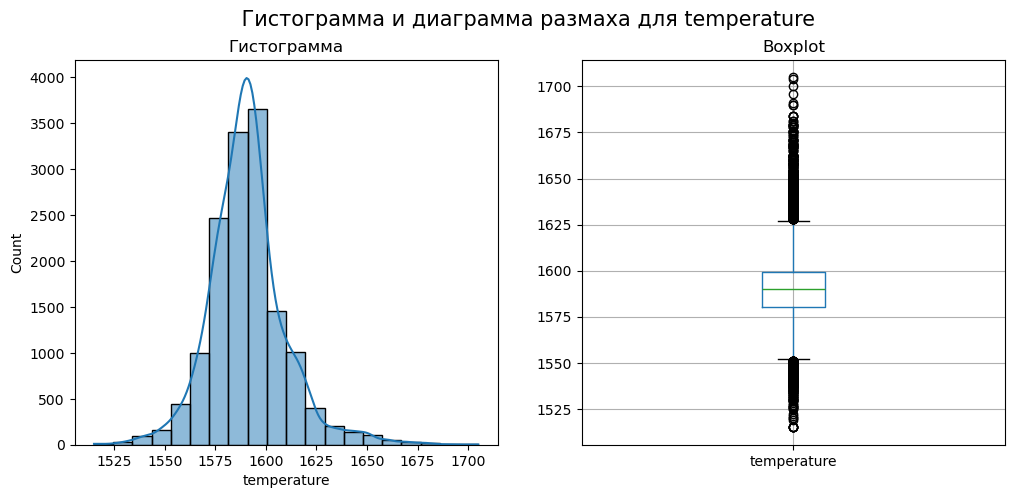

In [57]:
hist_and_boxplot('temperature', df_temp, bins=20)

Укаазано, что целевой признак — последняя температура партии. Начальную температуру партии можно использовать как входной признак. Любые другие промежуточные значения температуры приведут к утечке целевого признака, их нельзя использовать как входные.

Поэтому агрегируем данные по номеру партии и для каждой партии найдем значения первого `first_temp` и последнего измерения температуры `final_temp`, а также время измерений (`first_time` и `last_time`, соответственно)  и длительность между ними - `measure_time`.    

In [58]:
agg_temp = df_temp.groupby('key')

# Индексы строк с минимальным и максимальным временем
idx_min = agg_temp['measure_time'].idxmin()
idx_max = agg_temp['measure_time'].idxmax()

agg_df_temp = pd.DataFrame({
    'key': idx_min.index,
    'first_time': df_temp.loc[idx_min, 'measure_time'].values,
    'last_time':  df_temp.loc[idx_max, 'measure_time'].values,
    'first_temp': df_temp.loc[idx_min, 'temperature'].values,
    'last_temp':  df_temp.loc[idx_max, 'temperature'].values,
})

agg_df_temp['measure_time'] = (agg_df_temp['last_time'] - agg_df_temp['first_time']).dt.total_seconds() # общее время замера
agg_df_temp['measure_time']=agg_df_temp['measure_time'].astype('int')

Если для партии выполнено только одно измерение температуры или данные по температуре утеряны, то такие строки следует удалить.

In [59]:
agg_df_temp = agg_df_temp[agg_df_temp['measure_time'] != 0]
agg_df_temp = agg_df_temp.dropna()

In [60]:
display_info(agg_df_temp)

<class 'pandas.core.frame.DataFrame'>
Index: 2475 entries, 0 to 2476
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           2475 non-null   int64         
 1   first_time    2475 non-null   datetime64[ns]
 2   last_time     2475 non-null   datetime64[ns]
 3   first_temp    2475 non-null   float64       
 4   last_temp     2475 non-null   float64       
 5   measure_time  2475 non-null   int32         
dtypes: datetime64[ns](2), float64(2), int32(1), int64(1)
memory usage: 125.7 KB
----------------------------------------


,key,first_time,last_time,first_temp,last_temp,measure_time
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,1714
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,1265
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,1753
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,1220
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,1536


----------------------------------------------------------------------------------------------------


Таким образом, в `agg_df_temp` для каждой партии собраны ключевые температурные метрики: значения первого и последнего измерений температуры, соответствующие им времена измерений, а также интервал между замерами.

### Таблица `df_wire`

In [61]:
display_info(df_wire, n = 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   object 
 3   Wire 3  63 non-null     object 
 4   Wire 4  14 non-null     object 
 5   Wire 5  1 non-null      object 
 6   Wire 6  73 non-null     object 
 7   Wire 7  11 non-null     object 
 8   Wire 8  19 non-null     object 
 9   Wire 9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB
----------------------------------------


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None


----------------------------------------------------------------------------------------------------


**Переименование колонок**

Приведем названия всех столбцов датафрейма к формату *snake_case*.

In [62]:
df_wire.columns = df_wire.columns.str.lower().str.replace(' ', '_', regex=False)
df_wire.columns

Index(['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6',
       'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

**Контроль пропусков и дубликатов** 

In [63]:
check_missing_and_duplicates(df_wire)

Количество строк: 3081

Количество пропусков во всем датафрейме: 23385
Количество пропусков по столбцам:
key          0
wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3081


Т.к. пропуск означает, что материал не добавляли в эту партию, то заменим пропуски на нули.

In [64]:
df_wire = df_wire.fillna(0)

print(f"Количество пропусков после преобразований: {df_wire.isna().sum().sum()}")

Количество пропусков после преобразований: 0


**Преобразование типов данных**

В некоторых колонках с данными об объеме подаваемых проволочных материалов установлен тип `object`, его следует привести к типу `float`.

In [65]:
float_cols = [f'wire_{i}' for i in range(2, 10)]
df_wire[float_cols] = df_wire[float_cols].astype('float64')

# Проверка типов данных
df_wire.dtypes

key         int64
wire_1    float64
wire_2    float64
wire_3    float64
wire_4    float64
wire_5    float64
wire_6    float64
wire_7    float64
wire_8    float64
wire_9    float64
dtype: object

**Исследовательский анализ данных**

In [66]:
# Базовая статистика
df_wire.describe()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
count,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000
mean,1623.426485,100.044411,17.712733,3.874524,0.261019,0.004911,1.137695,0.035842,0.330697,0.321492
std,932.996726,42.841120,33.517734,30.310417,4.293865,0.272615,8.958111,0.774190,4.392677,3.806904
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,823.000000,70.281120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1619.000000,100.114563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2434.000000,125.798405,23.162880,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132000,180.454575,32.847674,102.762401,90.053604


Минимальное значение объема подаваемых проволочных материалов равно 0. Медиана для большинства колонок тоже ноль, т.к. много случаев когда подачи материала не было. Максиммальное значение варьируется от примерно 15 до 385 условных единиц.

Посмотрим общее распределение всех подаваемых проволочных материалов, но без учета нулевых объемов.

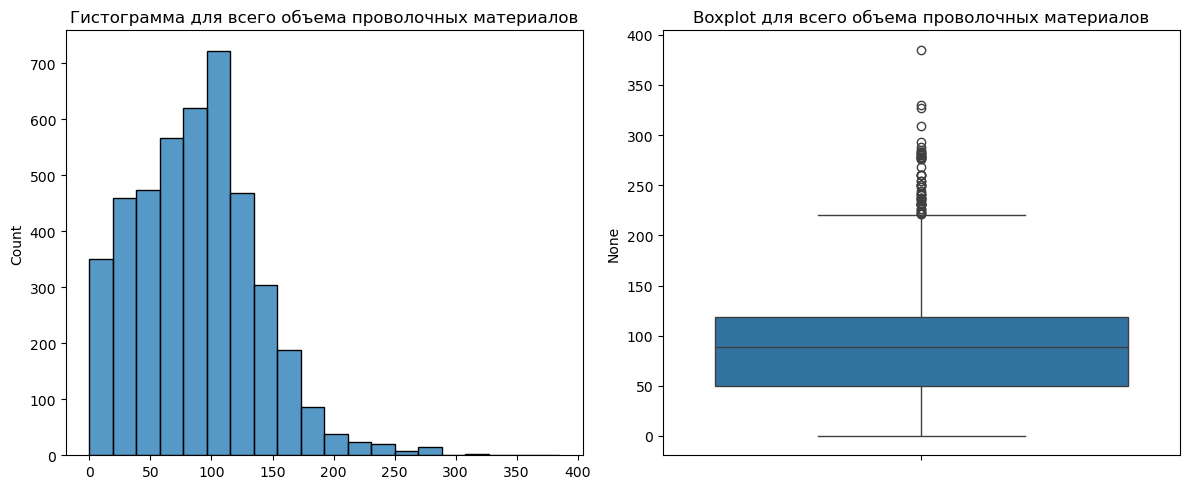

In [67]:
wire_cols = [f'wire_{i}' for i in range(1, 10)]
wire_all = df_wire[wire_cols].replace(0, np.nan).stack().dropna()

# Гистрограмма и диаграмма размаха
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(wire_all, bins=20)
plt.title("Гистограмма для всего объема проволочных материалов")
plt.subplot(1, 2, 2)
sns.boxplot(y=wire_all)
plt.title("Boxplot для всего объема проволочных материалов")
plt.tight_layout()
plt.show()

Объем подаваемых проволочных материалов в среднем около 100 у.е, но может достигать практически 400 у.е. 

Также как и в случае с сыпучими материалами введем новый признак - суммарный объем подаваемых проволочных материалов для каждой партии. 

In [68]:
df_wire['wire_sum'] = df_wire[wire_cols].sum(axis=1)
df_wire_new = df_wire[['key', 'wire_sum']].copy()

### Таблица `df_wire_time`

In [69]:
display_info(df_wire_time, n=3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB
----------------------------------------


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None


----------------------------------------------------------------------------------------------------


**Переименование колонок**

In [70]:
df_wire_time.columns = df_wire_time.columns.str.lower().str.replace(' ', '_', regex=False)
df_wire_time.columns

Index(['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6',
       'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

**Контроль пропусков и дубликатов** 

In [71]:
check_missing_and_duplicates(df_wire_time)

Количество строк: 3081

Количество пропусков во всем датафрейме: 23385
Количество пропусков по столбцам:
key          0
wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 3081


**Преобразование типов данных**

In [72]:
date_cols = [f'wire_{i}' for i in range(1, 10)]

for col in date_cols:
    df_wire_time[col] = pd.to_datetime(df_wire_time[col], errors='coerce')

**Исследовательский анализ данных**

In [73]:
df_wire_time.describe()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
count,3081.000000,3055,1079,63,14,1,73,11,19,29
mean,1623.426485,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,1.000000,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,823.000000,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,1619.000000,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2434.000000,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,3241.000000,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23
std,932.996726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Аналогично, проверим, что подача проволочных материалов не измеряется сутками.

In [74]:
diff = df_wire_time[date_cols].max(axis=1)-df_wire_time[date_cols].min(axis=1)
# Интервал подачи проволочных материалов в секундах
df_wire_time['wire_time'] = diff.dt.total_seconds()
df_wire_time['wire_time']=df_wire_time['wire_time'].astype('int')
# Интервал подачи проволочных материалов в часах
df_wire_time['wire_hours'] = df_wire_time['wire_time'] / 3600

# Время последней подачи проволочных материалов
df_wire_time['wire_last_time'] = df_wire_time[date_cols].max(axis=1)

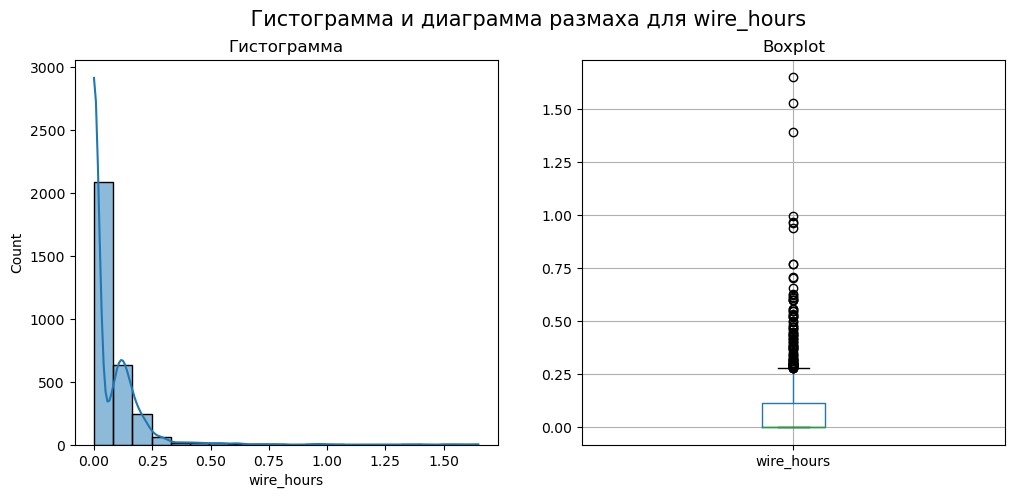

In [75]:
hist_and_boxplot('wire_hours', df_wire_time, bins=20)

Распределение длительности подачи проволочных материалов тоже похоже на распределение Пуассона: преобладают короткие интервалы, также встречаются и более продолжительные - до полутора часов. Однако экстремально больших временных интервалов нет.


In [76]:
df_wire_time_new = df_wire_time[['key', 'wire_time', 'wire_last_time']].copy()

### Объединение таблиц

Нужно объединить таблицы по ключу (номер партии `key`), с условием, что каждой партии должно соответствовать одно наблюдение.


In [77]:
data = agg_df_arc.copy()

for df in [df_bulk_new, df_bulk_time_new, df_gas, agg_df_temp, df_wire_new, df_wire_time_new]:
    data = pd.merge(
        data,                 
        df,
        on='key',
        how='inner',
        validate='one_to_one' 
    )

Проверим, чтобы время последнего измерения температуры было позже последнего времени подачи сыпучих и проволочных материалов.

In [78]:
print(len(data[data['bulk_last_time'] > data['last_time']]))
len(data[data['wire_last_time'] > data['last_time']])

0


0

Убедившись, время последнего измерения температуры было позже последнего времени подачи сыпучих и проволочных материалов, удалим колонки с временем подачи материалов и измерением температуры.

In [79]:
data = data.drop(columns=['first_time', 'last_time', 'bulk_last_time', 'wire_last_time' ])

In [80]:
display_info(data, n=3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   key               2329 non-null   int64  
 1   heat_count        2329 non-null   int64  
 2   heat_time         2329 non-null   int32  
 3   mean_total_power  2329 non-null   float64
 4   mean_ratio_power  2329 non-null   float64
 5   total_energy      2329 non-null   float64
 6   bulk_sum          2329 non-null   float64
 7   bulk_time         2329 non-null   int32  
 8   gas               2329 non-null   float64
 9   first_temp        2329 non-null   float64
 10  last_temp         2329 non-null   float64
 11  measure_time      2329 non-null   int32  
 12  wire_sum          2329 non-null   float64
 13  wire_time         2329 non-null   int32  
dtypes: float64(8), int32(4), int64(2)
memory usage: 218.5 KB
----------------------------------------


,key,heat_count,heat_time,mean_total_power,mean_ratio_power,total_energy,bulk_sum,bulk_time,gas,first_temp,last_temp,measure_time,wire_sum,wire_time
0,1,5,1098,0.743747,1.421570,770.282114,553.0,1085,29.749986,1571.0,1613.0,1714,60.059998,0
1,2,4,811,0.647087,1.479201,481.760005,582.0,1000,12.555561,1581.0,1602.0,1265,96.052315,0
2,3,5,655,1.003845,1.396069,722.837668,544.0,983,28.554793,1596.0,1599.0,1753,91.160157,0


----------------------------------------------------------------------------------------------------


In [81]:
check_missing_and_duplicates(data)

Количество строк: 2329

Количество пропусков во всем датафрейме: 0

Количество явных дубликатов: 0

Количество уникальных значений в столбце 'key': 2329


Таким образом, в объединенном датафреме 2329 строк и 14 колонок. Каждая строка содержит входные признаки и целевую переменную для каждой партии стали. 

### Исследовательский анализ данных объединенной таблицы

In [82]:
# Базовая статистика
data.describe()

,key,heat_count,heat_time,mean_total_power,mean_ratio_power,total_energy,bulk_sum,bulk_time,gas,first_temp,last_temp,measure_time,wire_sum,wire_time
count,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000
mean,1251.832546,4.695578,807.647488,0.825538,1.371466,669.780462,609.630313,985.905968,11.375600,1587.240876,1593.365393,2322.899957,125.208530,209.708459
std,714.762400,1.606629,340.838388,0.160306,0.065985,319.488816,287.599678,815.668796,6.392041,23.792360,11.200915,1384.892092,63.683386,390.096311
min,1.000000,1.000000,57.000000,0.331897,1.099589,33.430208,19.000000,0.000000,0.008399,1515.000000,1541.000000,339.000000,1.918800,0.000000
25%,630.000000,4.000000,581.000000,0.714331,1.329128,457.864703,440.000000,501.000000,7.282948,1571.000000,1587.000000,1581.000000,89.013596,0.000000
50%,1255.000000,5.000000,778.000000,0.818378,1.372098,630.714148,609.000000,894.000000,10.100950,1587.000000,1593.000000,2047.000000,116.101440,0.000000
75%,1868.000000,6.000000,993.000000,0.921106,1.414695,841.398018,795.000000,1340.000000,14.216688,1603.000000,1598.000000,2791.000000,151.568558,396.000000
max,2499.000000,16.000000,4189.000000,1.572238,1.663366,4546.405812,3235.000000,13683.000000,77.995040,1660.000000,1653.000000,23674.000000,568.777664,5937.000000


**Количество запусков нагрева электродов `heat_count`**

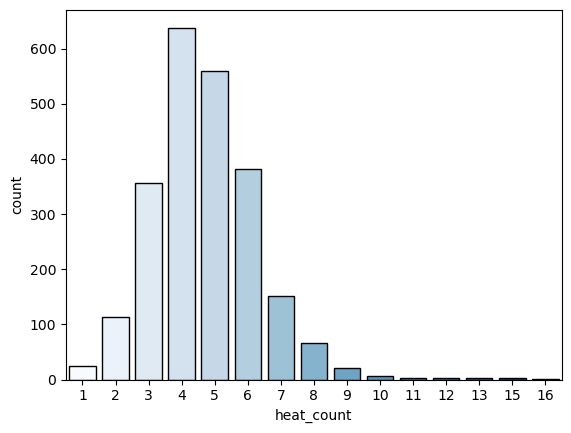

In [83]:
sns.countplot(x='heat_count', data=data, hue='heat_count', palette='Blues', edgecolor='black', legend=False)
plt.show()

Количество запусков нагрева электродов варируется от 1 до 16. В среднем большинство партий нагреваются 4-5 раз. При этом есть значительная доля партий стали, которые нагревались меньшим (2-3) и большим (6-7) числом запусков.

**Суммарное время нагрева электродов `heat_time`**

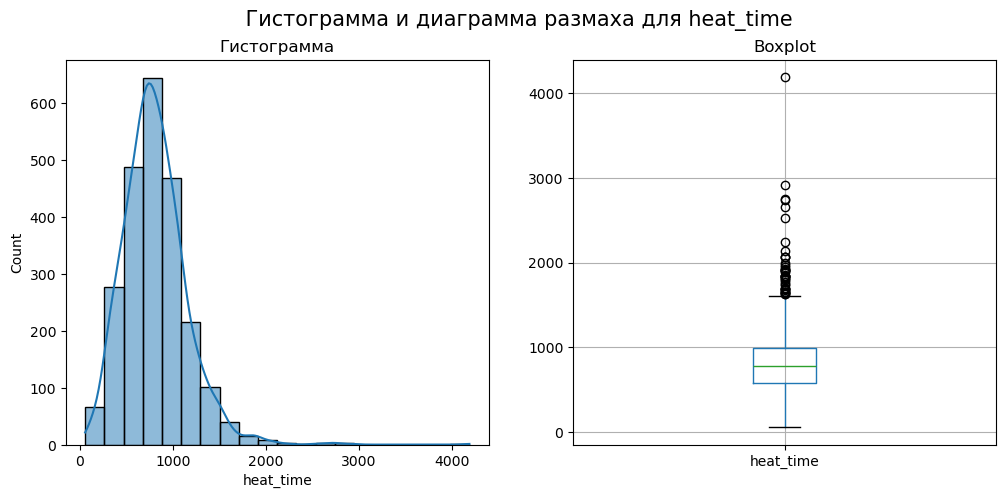

In [84]:
hist_and_boxplot('heat_time', data, bins=20)

Распределение времени нагрева электродов смещено вправо: среднее значение составляет порядка 800 секунд, при этом наблюдаются выбросы - отдельные значения доходят до 3000 секунд, а одно достигает 4000 секунд. Такие значения могут быть как следствием технических сбоев, так и реальными длительными циклами, обусловленными особенностью производственного процесса. 

Однако чтобы снизить влияние выбросов на последующее моделирование, необходимо отсечь наиболее экстремальные аномалии. Для этого заменим значения, превышающие порог `Q3+3*IQR` на эту верхнюю границу. 

In [85]:
# Замена экстремальных выбросов 
def upper_outliers(s):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR

    return s.clip(upper=upper_bound)

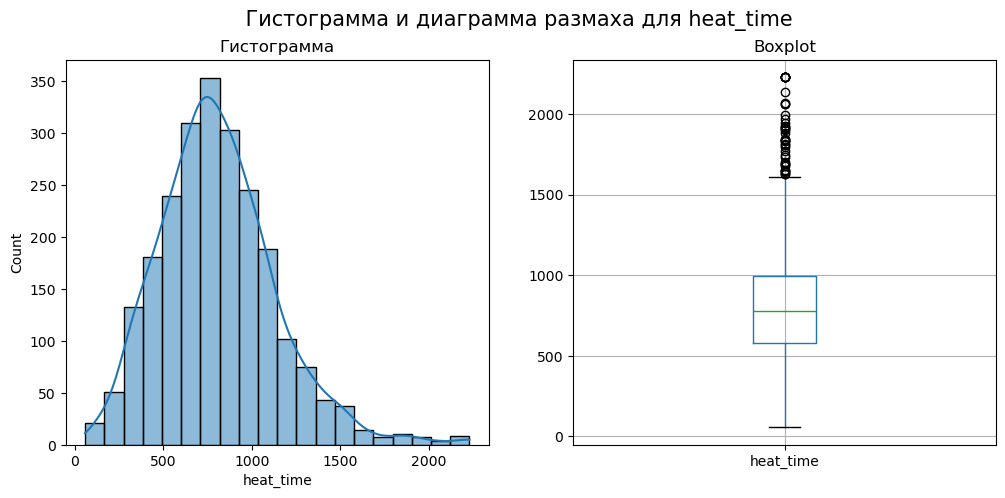

In [86]:
data['heat_time'] = upper_outliers(data['heat_time'])
hist_and_boxplot('heat_time', data, bins=20)

Основная форма распределения времени нагрева сохранилась. При этом хвост справа стал заметно короче: теперь значения не выходят за отметку в 2500 секунд.

**Средняя полная мощность электродов `mean_total_power`**

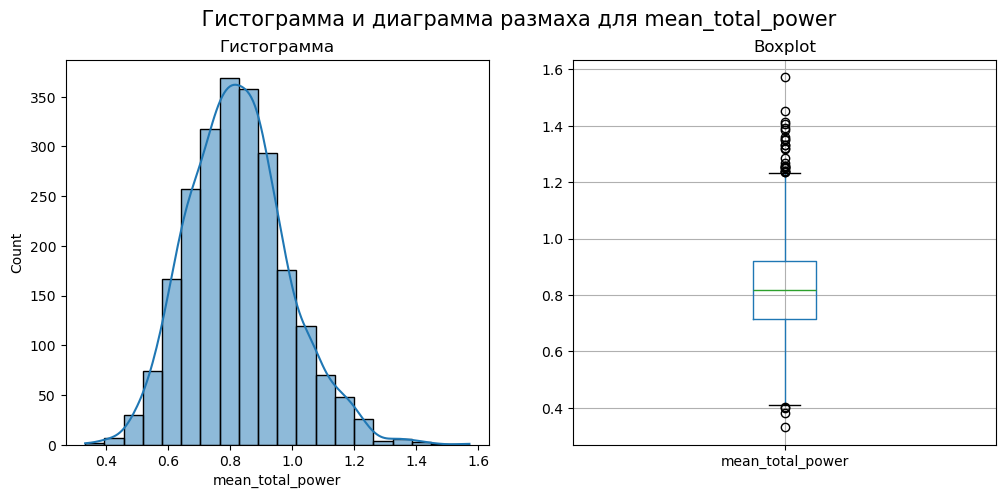

In [87]:
hist_and_boxplot('mean_total_power', data, bins=20)

Средняя полная мощность имееет распределение, близкое к нормальному: значения лежат в диапазоне от 0,4 до 1,6 у.е., а среднее значение примерно 0,8 у.е. При этом имеющиеся выбросы незначительны и не вносят сильного перекоса в общую картину: распределение остается достаточно симметричным.

**Среднее отношение мощностей электродов `mean_ratio_power`**

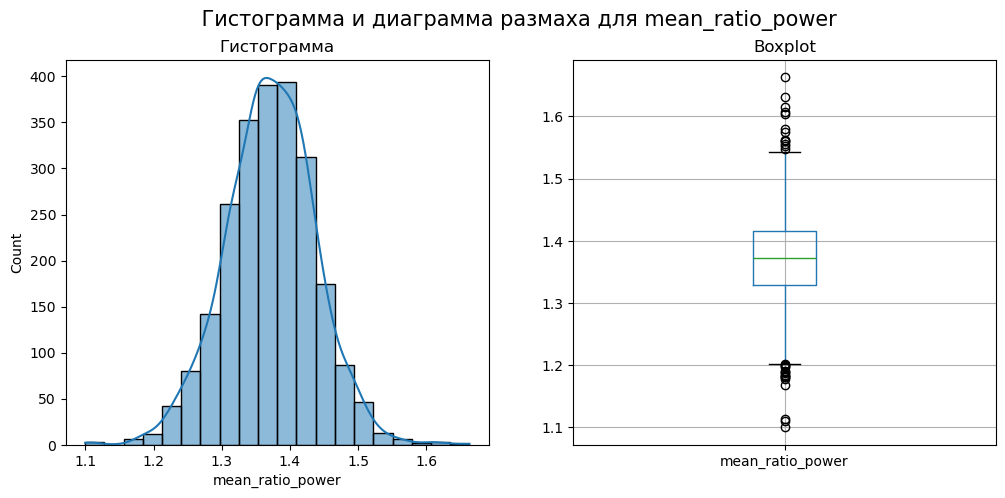

In [88]:
hist_and_boxplot('mean_ratio_power', data, bins=20)

Средняя отношение активной мощности к реактивной также имееет близкое к нормальному распределение: значения лежат в диапазоне от 1.1 до 1.7. 

**Суммарная энергия на нагрев `total_energy`**

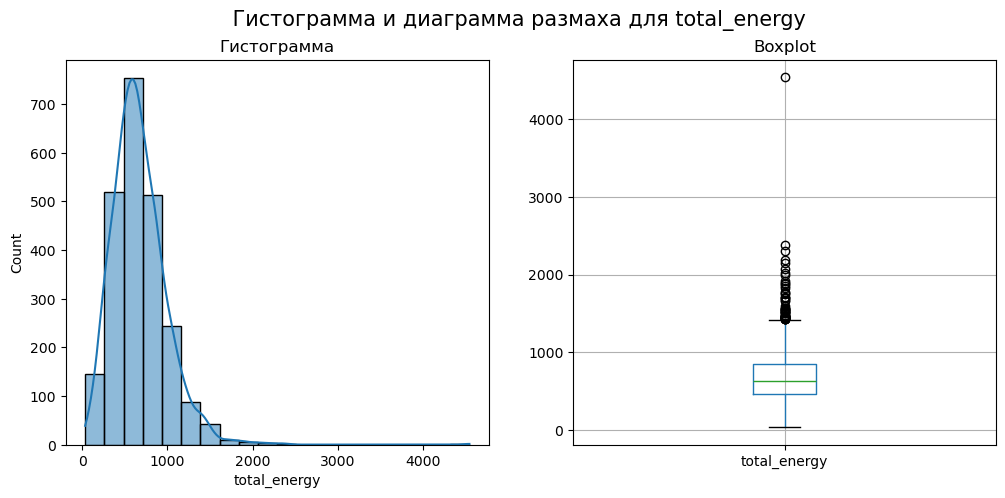

In [89]:
hist_and_boxplot('total_energy', data, bins=20)

Распределение энергии, потраченной на нагрев электродов, тоже имеет правостороннюю асимметрию и выраженные выбросы. Это логично, поскольку энергия напрямую зависит от средней мощности и длительности нагрева. Поэтому для обрезки выбросов используем тот же подход, что и для времени нагрева.  


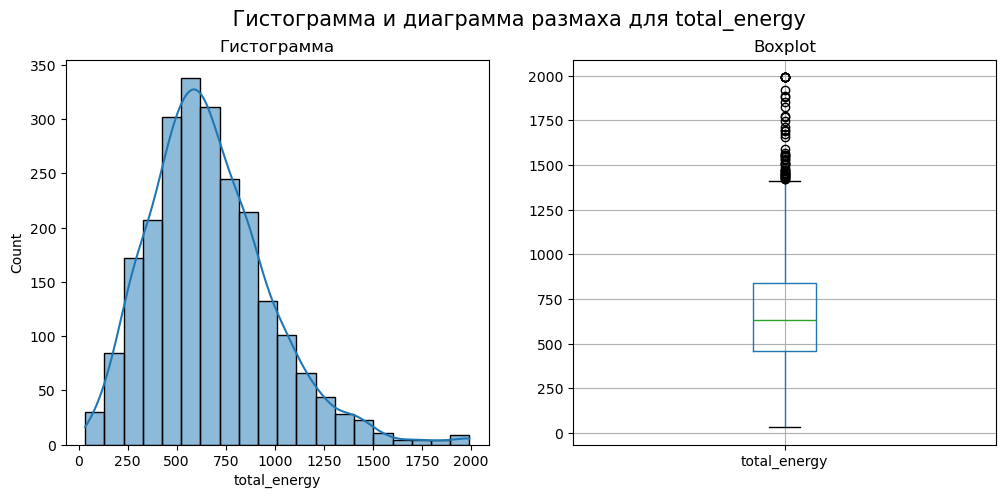

In [90]:
data['total_energy'] = upper_outliers(data['total_energy'])
hist_and_boxplot('total_energy', data, bins=20)

Распределение энергии стало более симметричным, теперь значения энергии не перевышают примерно 2000 у.е. 

**Суммарный объем добавленных сыпучих материалов `bulk_sum`**

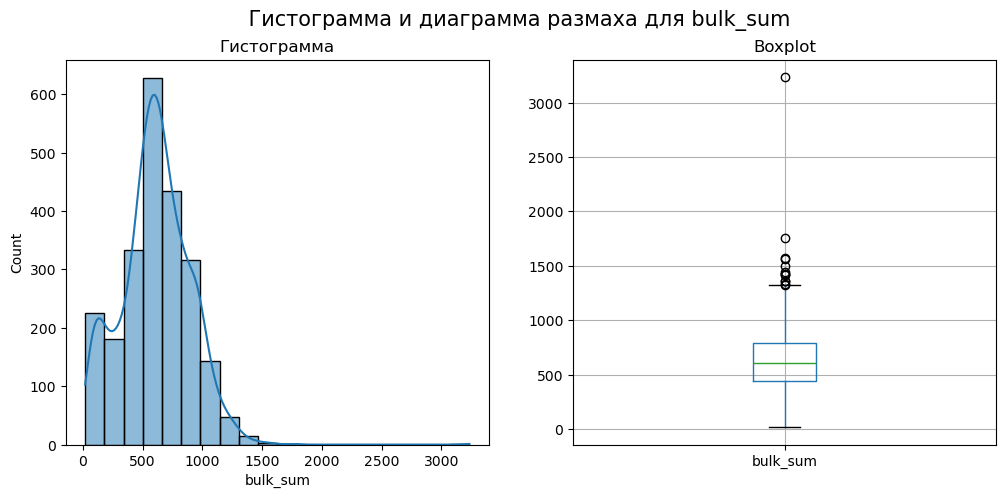

In [91]:
hist_and_boxplot('bulk_sum', data, bins=20)

Сначала также обработаем выбросы - аномально большие объемы добавленных материалов.

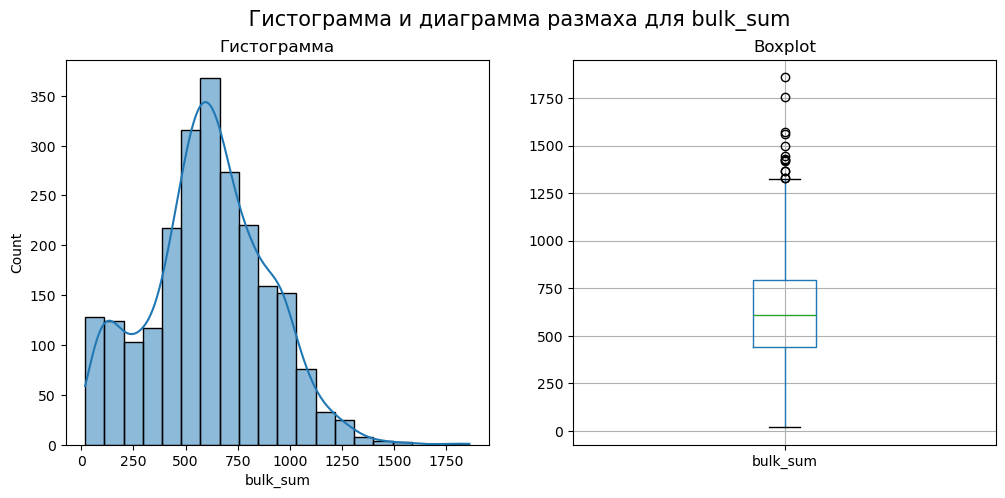

In [92]:
data['bulk_sum'] = upper_outliers(data['bulk_sum'])
hist_and_boxplot('bulk_sum', data, bins=20)

Суммарный объем добавленных сыпучих материалов имеет бимодальное распределение: заметен небольшой пик у левой границы (около к нулю). Он обусловлен партиями, в которых материал добавлялся крайне мало. Это следствие того, что пропуски в данных трактуются как нули.

**Интервал подачи сыпучих материалов `bulk_time`**

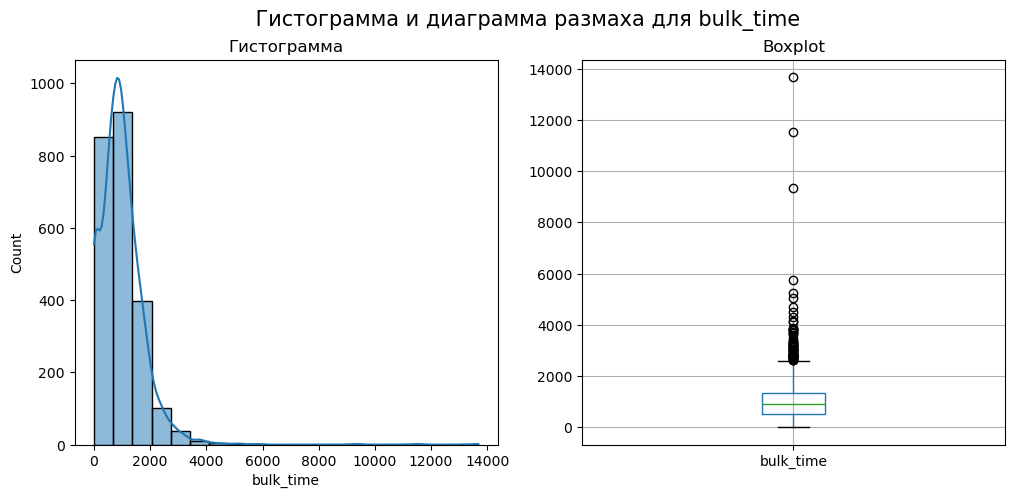

In [93]:
hist_and_boxplot('bulk_time', data, bins=20)

Интервалы подачи сыпучих материалов также имеют сильные выбросы, которые нужно обработать.

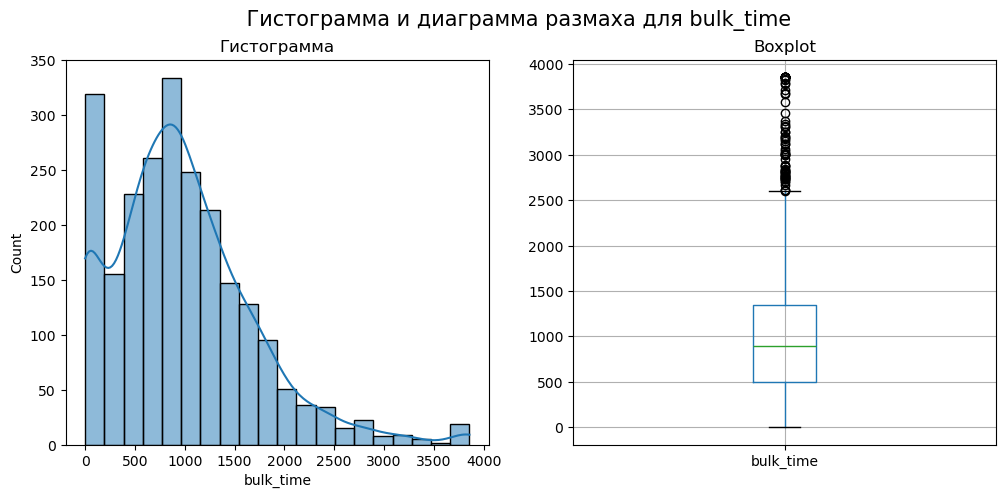

In [94]:
data['bulk_time'] = upper_outliers(data['bulk_time'])
hist_and_boxplot('bulk_time', data, bins=20)

Интервал времени между первой и последней подачей сыпучих материалов в партию имеет заметный пик у левой границы. Здесь это обусловленно тем, что если в партию сыпучие материалы добавлялись один раз, то интервал равен нулю. Видно, что таких партий довольно значительное количество. 

**Объем подаваемого газа `gas`**

Объем подаваемого газа берется из датафрейма `df_gas` без изменений. Там уже отмечалось, что в данных есть выбросы (большие значения объема газа), которые тоже можно обработать.

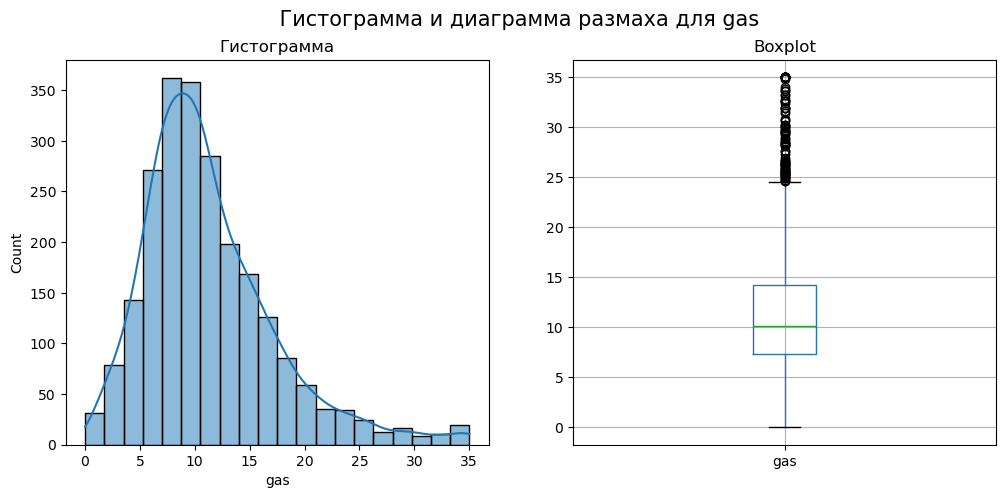

In [95]:
data['gas'] = upper_outliers(data['gas'])
hist_and_boxplot('gas', data, bins=20)

Теперь объем газа тоже имеет распределение с небольшой ассиметрией вправо: при среднем значение объема 10 у.е., максимальные значения достигают 35 у.е.

**Начальная температура стали `first_temp`**

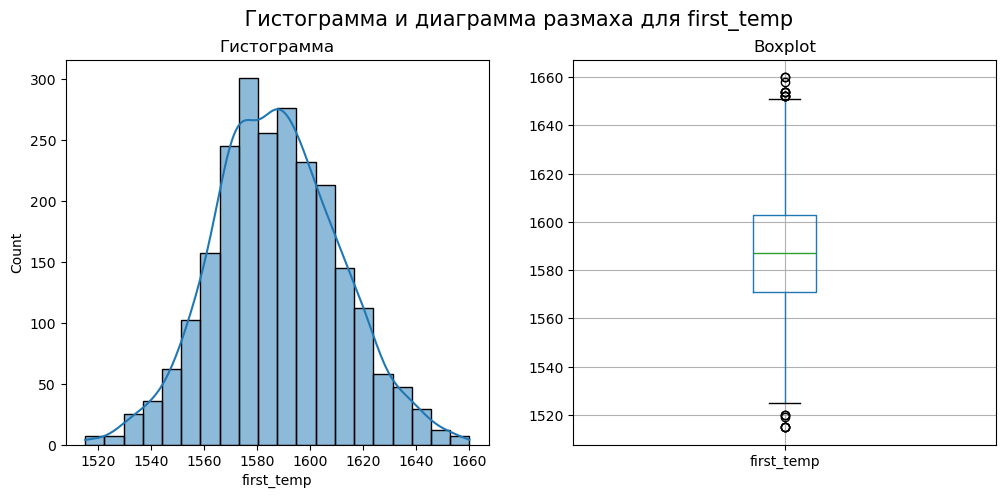

In [96]:
hist_and_boxplot('first_temp', data, bins=20)

Начальная температура стали имеет нормальное распределение, значения варьируются от 1520 до 1660 градусов. Средняя начальная температура около 1590 градусов.

**Финальная температура стали `last_temp`**

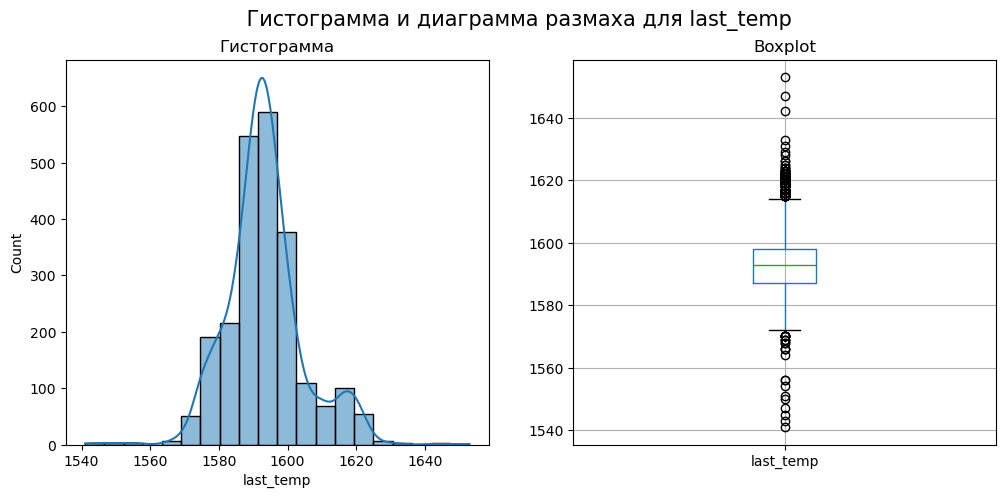

In [97]:
hist_and_boxplot('last_temp', data, bins=20)

Последняя измеренная температура стали варьируется в диапазоне от 1540 до 1650 градусов. При этом средняя финальная температура примерно совпадает со средней начальной. Это обусловлено характером производственного процесса: в ходе плавки сталь не только нагревается, но и неизбежно остывает.

**Интервал между измерениями температуры `measure_time`**

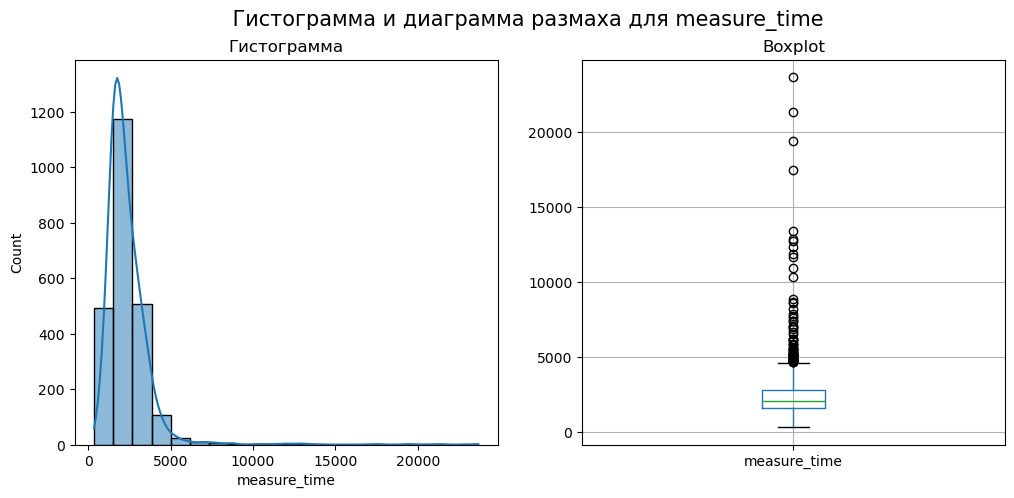

In [98]:
hist_and_boxplot('measure_time', data, bins=20)

Время между первым и последним измерениями температуры занимает в среднем около 2000 секунд(~0.5 часа), но в отдельных случаях достигает более 6 часов. Такой сильный разброс отражает неоднородность технологического процесса.

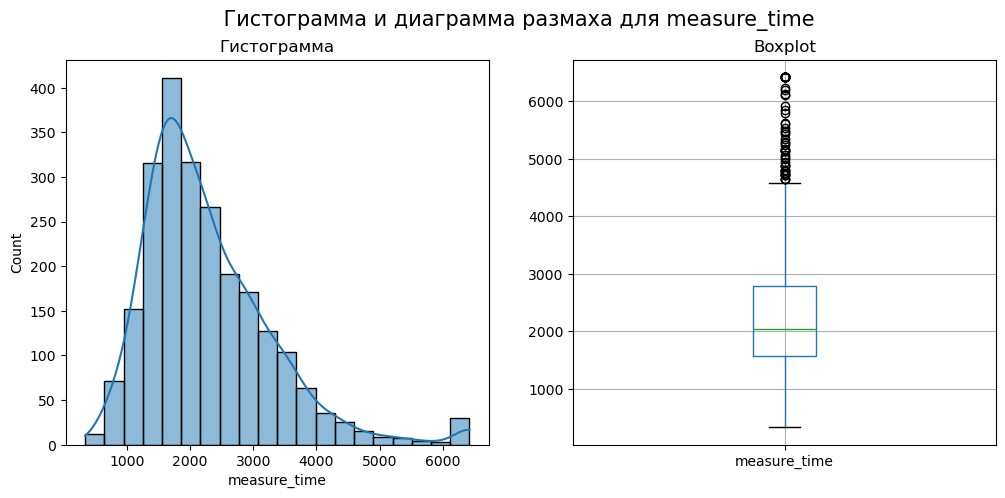

In [99]:
data['measure_time'] = upper_outliers(data['measure_time'])
hist_and_boxplot('measure_time', data, bins=20)

Теперь время между первым и последним измерениями температуры ограничено примерно 2 часами. Это существенно сократило длинный хвост распределения.


**Суммарный объем подаваемых проволочных материалов `wire_sum`**

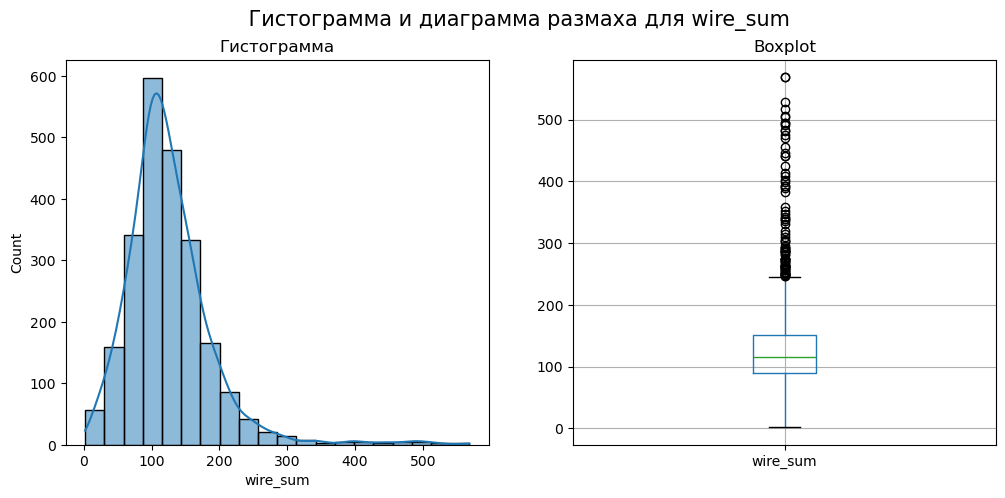

In [100]:
hist_and_boxplot('wire_sum', data, bins=20)

Суммарный объем проволочных материалов также имеет длинный хвост, который необходимо обрезать.

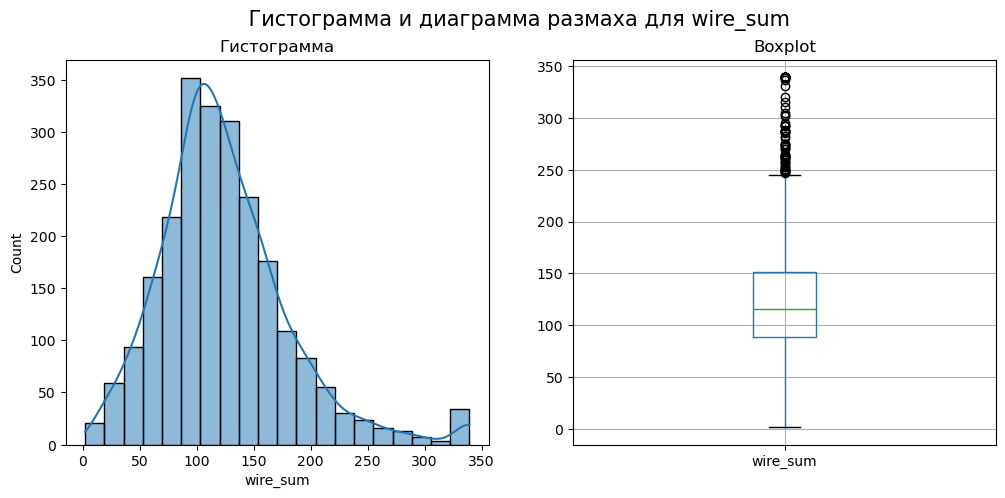

In [101]:
data['wire_sum'] = upper_outliers(data['wire_sum'])
hist_and_boxplot('wire_sum', data, bins=20)

Суммарный объем проволочных материалов достигает 350 у.е. при среднем значении около 120.

**Интервал подачи проволочных материалом `wire_sum`**

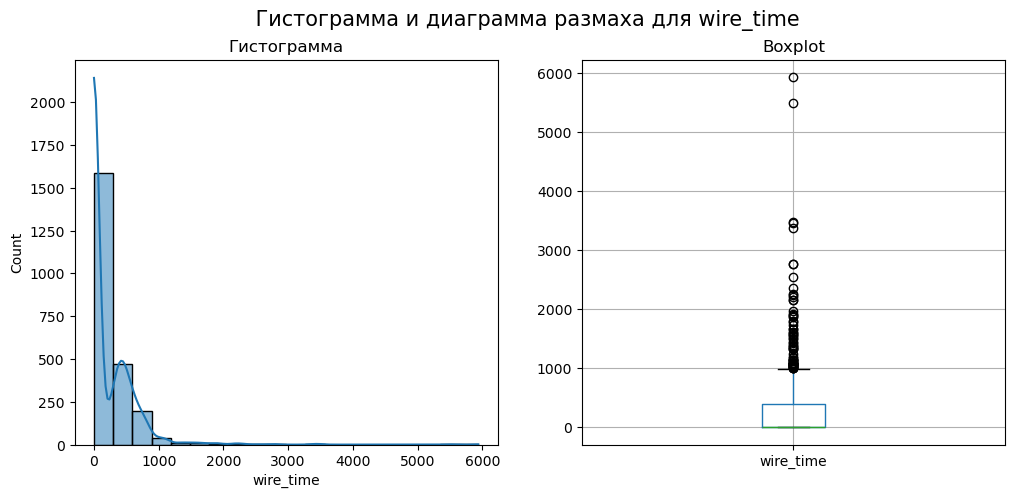

In [102]:
hist_and_boxplot('wire_time', data, bins=20)

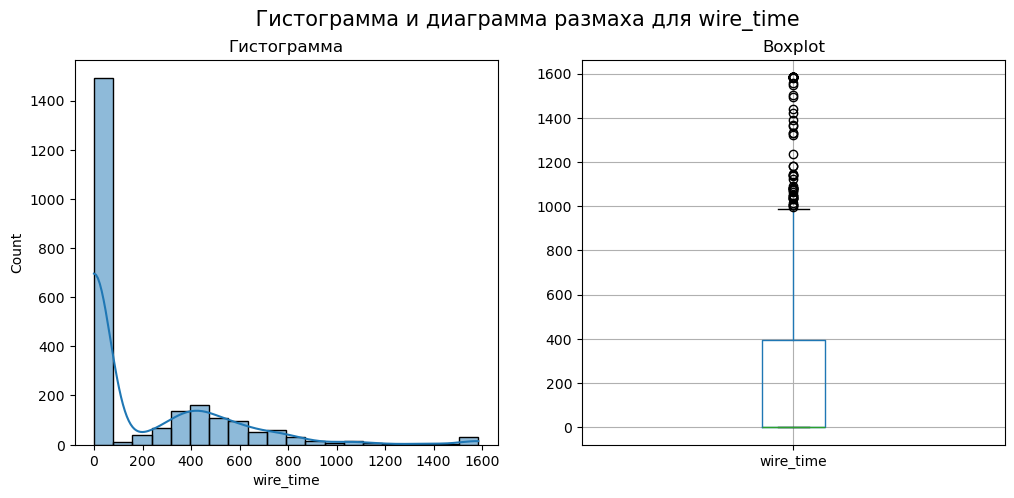

In [103]:
data['wire_time'] = upper_outliers(data['wire_time'])
hist_and_boxplot('wire_time', data, bins=20)

Интервал времени между первой и последней подачей проволочных материалов в партию имеет оргомный пик у нуля. Т.е. большая часть проволочных материалов добавлялась в партию за один раз.

### Корреляционный анализ данных

Построим матрицу корреляции

In [104]:
interval_cols = ['heat_count', 'heat_time', 'mean_total_power', 'mean_ratio_power',  'total_energy', 'bulk_sum', \
                 'bulk_time', 'gas', 'first_temp', 'last_temp', 'measure_time', 'wire_sum', 'wire_time']

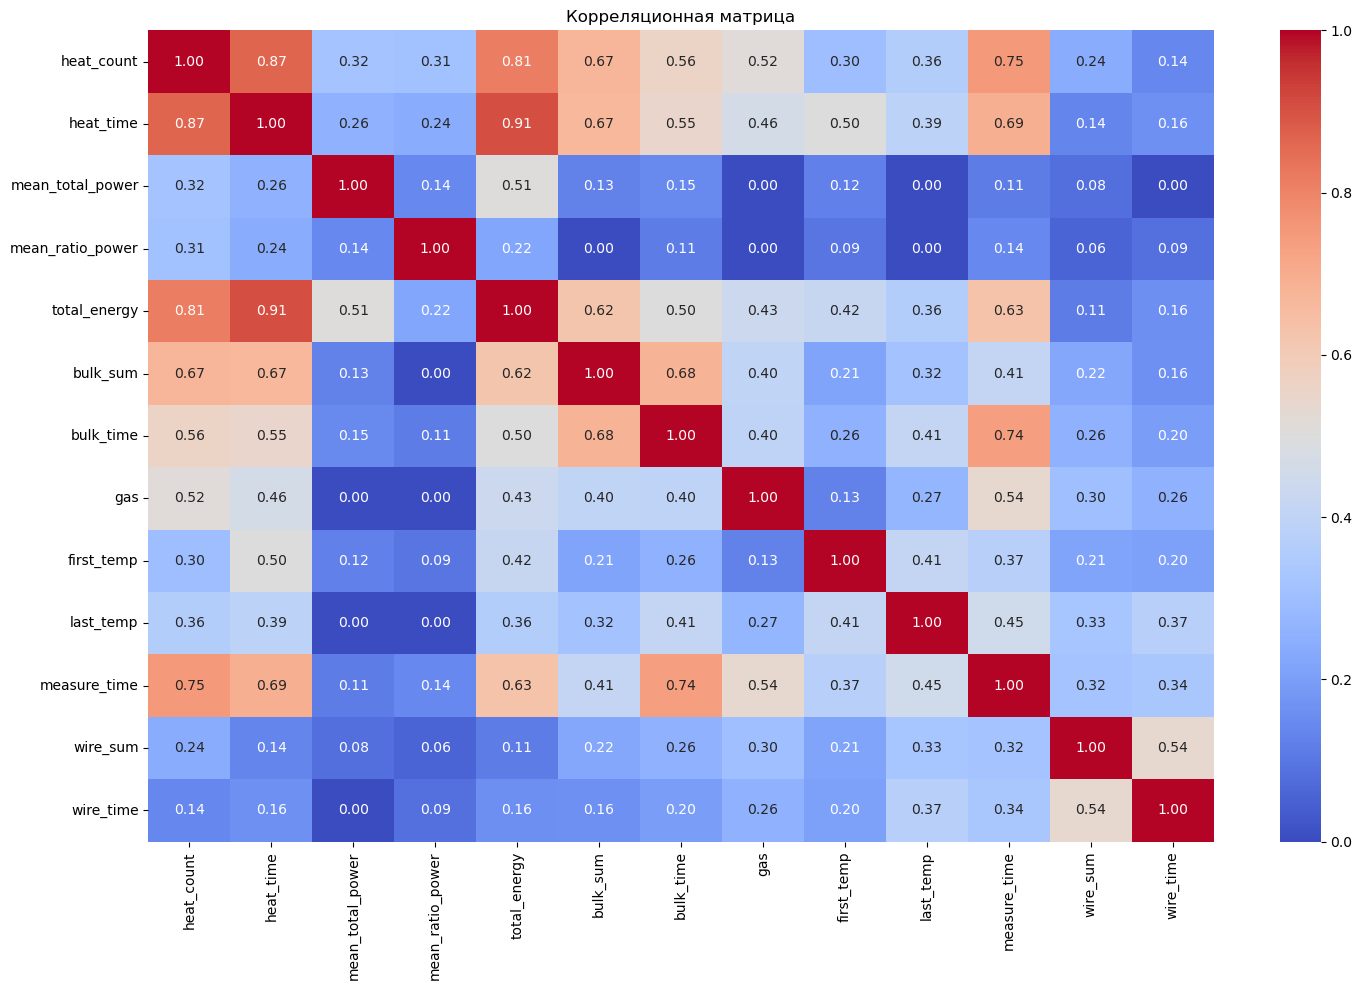

In [105]:
phik_matrix = data.drop('key', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

Видно, что целевой признак **last_temp** сильнее всего коррелирует с признаками `bulk_time`, `first_temp` и `measure_time`. Однако это корреляция довольно слабая.

У входных признаков видна высокая корреляция между `heat_time` и `total_energy`, `heat_time` и `heat_count`, `heat_time` и `heat_count`. Это ожидаемо: энергия по определению зависит от времени нагрева, а число нагревов коррелирует с общей длительностью нагрева.
Удалим по одному признаку из пары: 'heat_count', 'total_energy'.

In [106]:
data = data.drop(columns=['heat_count', 'total_energy'])

### Подготовка данных для обучения

In [107]:
# устанавливаем столбец 'key' в качестве индекса
data = data.set_index('key')
data.head()

,heat_time,mean_total_power,mean_ratio_power,bulk_sum,bulk_time,gas,first_temp,last_temp,measure_time,wire_sum,wire_time
key,,,,,,,,,,,
1,1098,0.743747,1.421570,553.0,1085,29.749986,1571.0,1613.0,1714,60.059998,0
2,811,0.647087,1.479201,582.0,1000,12.555561,1581.0,1602.0,1265,96.052315,0
3,655,1.003845,1.396069,544.0,983,28.554793,1596.0,1599.0,1753,91.160157,0
4,741,0.850010,1.307446,595.0,878,18.841219,1601.0,1625.0,1220,89.063515,0
5,869,0.704245,1.328894,584.0,205,5.413692,1576.0,1602.0,1536,98.352796,310


In [108]:
# Определяем целевой и входные признаки
X = data.drop(['last_temp'], axis=1)
y = data['last_temp']

# Разделяем набор данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25, 
    random_state = RANDOM_STATE)

**В результате, были проведены исследовательский анализ и предобработка данных.** 

* Для всех датафреймов были изменены названия колонок и типы данных при необходимости;
* Для всех датафреймов изучены и заполнены пропуски, данные проверены на наличие явных дубликатов;
* Проведен ИАД, исправлены аномальные значения;
* Получены новые признаки, необходимые для моделирования;
* Все датафреймы были объединены по номеру партии;
* Проведен ИАД для нового датафрейма: построены распределения данных, проведена работа с выбросами;
* Проведен корреляционный анализ данных и отобраны признаки для обучения
* Данные подготовлены для обучения: определена целевая переменная, данные разделены на выборки.

Таким образом, можно приступать к обучению модели.  

## Обучение модели

Рассмотрим следующие классы моделей:
* случайный лес,
* бустинги LightGBM и XGBoost,
* нейронные сети.

Найдем лучшую модель для прогноза последней измеренной температуры `last_temp`, оценив её качество метрикой `MAE`.

###  RandomForest

В качестве базового решения используем `RandomForest`. Сначала подберем оптимальные гиперпараметры с помощью рандомизированного поиска. Модель с лучшими параметрами будем использовать для дальнейшего сравнения с другими алгоритмами.  

In [109]:
# Функция для нахождения модели с лучшими гиперпараметрами
def find_best_model(model, param_dist):
    
    # Настройка RandomSearchCV
    random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=True,
)

    # Запуск поиска
    random_search.fit(X_train, y_train)
    cv_results = random_search.cv_results_

    # Вывод результатов
    best_model = random_search.best_estimator_
    best_param = random_search.best_params_
    best_metric = -random_search.best_score_
    print('Лучшие параметры:', best_param)
    print ('Лучший MAE на CV:', round(best_metric, 2))
    
    return best_model, best_param, best_metric

In [110]:
# Гиперпараметры RandomForestRegressor
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

In [111]:
model_rf = RandomForestRegressor(random_state=RANDOM_STATE)
best_model_rf,  best_param_rf, result_rf = find_best_model(model_rf, param_dist_rf)

Лучшие параметры: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}
Лучший MAE на CV: 6.41


### LightGBM

Аналогично, сначала подберем лучшие гиперпараметры и затем оценим качество модели.

In [112]:
# Гиперпараметры LGBMRegressor
param_dist_lgb = {
    'n_estimators': [200, 300, 400],
    'num_leaves': [10, 15, 20],
    'max_depth': [-1, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'min_child_samples': [3, 5, 7]
}

In [113]:
model_lgb = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
best_model_lgb,  best_param_lgb, result_lgb = find_best_model(model_lgb, param_dist_lgb)

Лучшие параметры: {'num_leaves': 10, 'n_estimators': 400, 'min_child_samples': 3, 'max_depth': -1, 'learning_rate': 0.03}
Лучший MAE на CV: 6.22


### XGBoost

In [114]:
# Гиперпараметры XGBRegressor
param_dist_xgb = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'min_child_weight': [2, 4, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [115]:
model_xgb =  XGBRegressor(random_state=RANDOM_STATE, eval_metric='mae')
best_model_xgb, best_param_xgb, result_xgb = find_best_model(model_xgb, param_dist_xgb)

Лучшие параметры: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Лучший MAE на CV: 6.24


### Нейронная сеть

In [116]:
# Копируем данные
X_full, y_full = X_train.copy(), y_train.copy()

# Делим на тренировочную и валидационную выборки
X_train_2, X_val, y_train_2, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE
)

Для нейронных сетей сначала выполним стандартизацию признаков. 

In [117]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_2)
X_val_s = scaler.transform(X_val)

In [118]:
# Тензоры
X_train_t = torch.FloatTensor(X_train_s)
X_val_t   = torch.FloatTensor(X_val_s)
y_train_t = torch.FloatTensor(y_train_2.values)
y_val_t   = torch.FloatTensor(y_val.values)

Создадим класс для задания архитектуры нейронной сети. Как базу возьмем 1 скрытый слой и ReLU в качестве функции активации, т.к. у нас задача регрессии.

In [119]:
class NeuralNet(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons, n_out_neurons, activation_fn=nn.ReLU):
        super().__init__()
        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons)
        self.act1 = activation_fn()
        self.fc2 = nn.Linear(n_hidden_neurons, n_out_neurons)
      
    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        return x

Создадим функцию для обучения нейронной сети, которая будет искать лучший результат по `MAE`. В качестве параметров будут: model, optimizer, а также обучающие и валидационные выборки.

In [120]:
def train_neural_net(model, optimizer, X_train, y_train, X_val, y_val, patience=30, num_epochs=5000):
    loss_fn = nn.L1Loss() 

    best_mae = float('inf')
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        # Обучение
        model.train()
        optimizer.zero_grad()

        preds = model(X_train).flatten()
        mae_loss = loss_fn(preds, y_train)
        
        mae_loss.backward()
        optimizer.step()

        # Валидация
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val).flatten()
            val_mae = loss_fn(val_preds, y_val)

        current_mae = val_mae.item()

        if current_mae < best_mae:
            best_mae = current_mae
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_mae, best_epoch, model

Количество нейронов на выходном и выходном слоях будет фиксированно:
n_in_neurons = X_train.shape[1];
n_out_neurons = 1.

Количество нейронов на скрытом слое будем варьировать. 

In [121]:
hidden_configs = [4, 6, 8, 10]
activation_fn = nn.ReLU

best_mae = float('inf')
best_config = None
best_model = None
results = {}

for n_hidden in hidden_configs:
    model = NeuralNet(
        n_in_neurons=X_train.shape[1],
        n_hidden_neurons=n_hidden,
        n_out_neurons=1,
        activation_fn=activation_fn
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

    mae, epoch, trained_model = train_neural_net(
        model, optimizer, X_train_t, y_train_t, X_val_t, y_val_t, patience=30
    )

    config_key = f"hidden={n_hidden}"
    results[config_key] = {'mae': mae, 'epoch': epoch}

    print(f"n_hidden_neurons={n_hidden:<10} MAE={mae:<10.4f} epoch={epoch}")
    print("-" * 55)
    
    if mae < best_mae:
        best_mae = mae
        best_config = n_hidden
        best_model = trained_model

print("Лучшие параметры: n_hidden_neurons=", best_config)
print("Лучший MAE:", round(best_mae, 2))

n_hidden_neurons=4          MAE=6.5604     epoch=4562
-------------------------------------------------------
n_hidden_neurons=6          MAE=6.9044     epoch=3121
-------------------------------------------------------
n_hidden_neurons=8          MAE=6.8391     epoch=3295
-------------------------------------------------------
n_hidden_neurons=10         MAE=7.0553     epoch=3133
-------------------------------------------------------
Лучшие параметры: n_hidden_neurons= 4
Лучший MAE: 6.56


### Cравнение моделей

In [122]:
# Датафрейм с результатами
results_df = pd.DataFrame({
    'Model': ['RandomForest', 'LightGBM', 'XGBoost','NeuralNet'],
    'MAE': [result_rf, result_lgb, result_xgb, best_mae]
})

table = results_df.style \
    .format({'MAE': '{:.2f}'}) \
    .set_properties(**{'padding': '8px 12px'})

display(table)

,Model,MAE
0,RandomForest,6.41
1,LightGBM,6.22
2,XGBoost,6.24
3,NeuralNet,6.56


Все модели показали достойный результат - средняя абсолютная ошибка для всех моделей меньше 6.6, что для задачи прогнозирования финальной температуры в производственном процессе можно считать хорошим показателем.   

Лучший результат у `LightGBM`, на втором месте по качеству `XGBoost`. Бустинги имеют преимущество за счет подстройки под особенности выборки и способности улавливать нелинейные зависимости.

У `RandomForest` тоже хороший результат. Это говорит о том, что структура данных хорошо улавливается деревьями.

`NeuralNet` немного отстаёт. Нейросети требуют более тонкой настройки параметров и регуляризация.

**В результате, была были обучены несколько моделей: `RandomForest`, градиентные бустинги `LightGBM` и `XGBoost`, а также нейронная сеть.** Для каждой модели с помощью рандомизированного поиска (*RandomizedSearchCV*) были подобраны оптимальные гиперпараметры, позволяющие достичь наилучшей метрики `MAE`.

Лучший результат показала модель градиентного бустинга `LightGBM`. Ее преимущество обусловлено способностью эффективно улавливать нелинейные зависимости и локальные закономерности в данных.


## Тестирование модели

Проверим качество лучшей модели на тестовой выборке. Значение метрики `MAE` должно быть менее 6.8. Дополнительно оценим `R²`.

In [123]:
best_model = best_model_lgb
test_predictions = best_model.predict(X_test)

print(f'MAE на тестовой выборке: {round(mean_absolute_error(y_test, test_predictions),2)}')
print(f'R2 на тестовой выборке: {round(r2_score(y_test, test_predictions),2)}')

MAE на тестовой выборке: 6.39
R2 на тестовой выборке: 0.43


### Сравнение результатов лучшей и константной моделей

В качестве константной модели берем `DummyRegressor`.

In [124]:
dummy = DummyRegressor(strategy='median')

dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)  

print(f'MAE константной модели: {mae_dummy:.2f}')
print(f'R² константной модели:  {r2_dummy:.2f}')

MAE константной модели: 8.28
R² константной модели:  -0.00


По сравнению с константной моделью полученная модель (`LightGBM`) снижает `MAE` на 1.89 (градус).`R²` вырос до 0.43, т.е. модель объясняет 43% разброса значений температуры. 

Таким образом,  модель улавливает закономерности и может использоваться для прогноза последней измеренной температуры. 

### Анализ важности основных признаков
Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP.

In [125]:
explainer = shap.Explainer(best_model.predict, X_train, feature_names=X_train.columns)
shap_values = explainer(X_train)

ExactExplainer explainer: 1747it [18:17,  1.58it/s]                                                                    


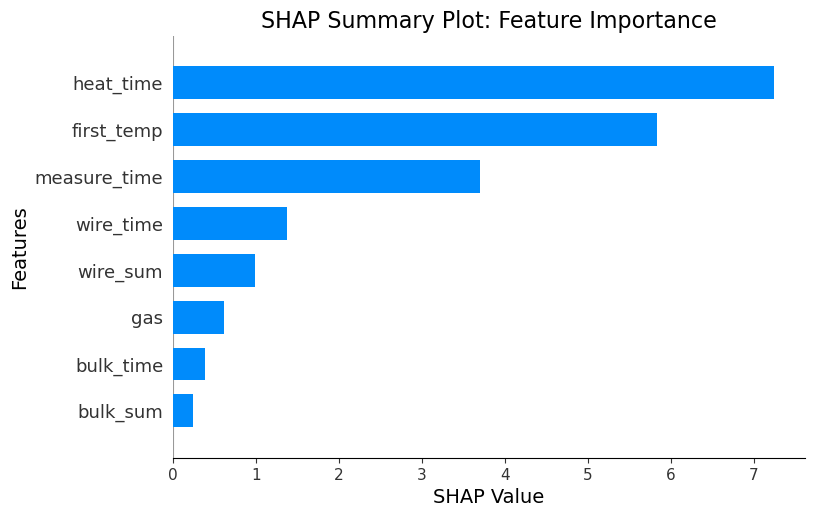

In [126]:
rng = np.random.default_rng()
shap.summary_plot(
    shap_values, 
    X_train, 
    plot_type="bar", 
    max_display=8, 
    plot_size=(8, 5), 
    rng=rng,
    show=False
)

fig, ax = plt.gcf(), plt.gca()

# настраиваем заголовок и оси
ax_title = 'SHAP Summary Plot: Feature Importance'
font_size = 16
ax.set_title(ax_title, fontdict={"size": font_size})
ax.set_xlabel('SHAP Value', fontsize=14)
ax.set_ylabel('Features', fontsize=14)
# показываем график
plt.show()

Наиболее важными признаками при определении финальной температуры являются время нагрева электродов, начальная температура и интервал между измерениями температуры. 
* Время нагрева электродов напрямую связано с подводом тепла;
* Начальная температура - это стартовая точка, она задает диапазон возможных финальных значений;
* От интервала между измерениями температуры зависит успеет ли сталь остыть за этот промежуток.

Меньшее влияние оказывают время подачи и объемы добавленных материалов. Например, холодные добавки могут снижать температуру.

### Дополнительное исследование для важного признака

Построим графики зависимости финальной температуры стали от двух наиважнейших признаков: времени нагрева и начальной температуры.

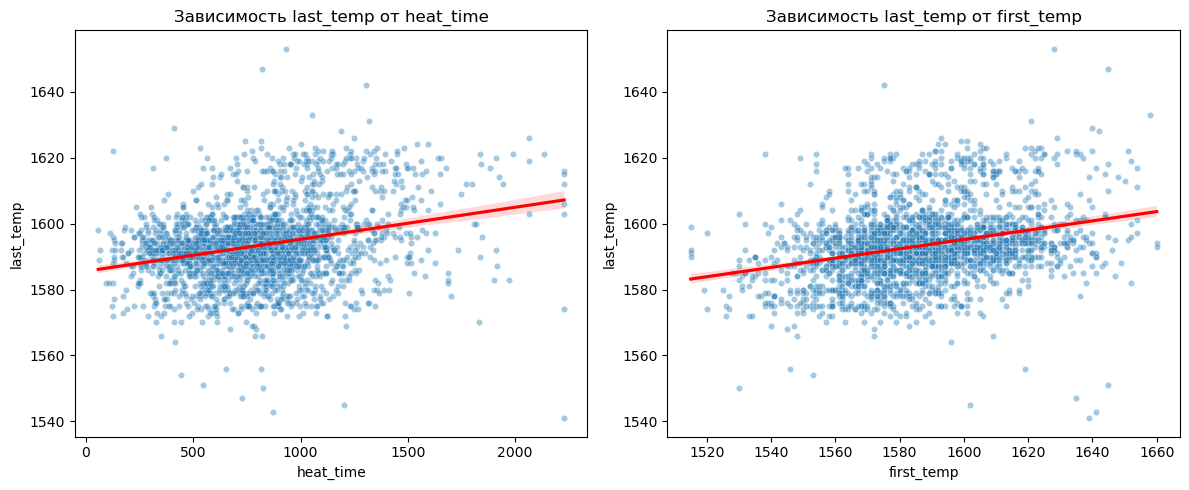

In [127]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
sns.scatterplot(x=data['heat_time'], y=data['last_temp'], alpha=0.4, s=20)
# Линейный тренд
sns.regplot(x=data['heat_time'], y=data['last_temp'], scatter=False, color='red')    
plt.title('Зависимость last_temp от heat_time')
plt.xlabel('heat_time')
plt.ylabel('last_temp')

plt.subplot(1, 2, 2) 
sns.scatterplot(x=data['first_temp'], y=data['last_temp'], alpha=0.4, s=20)
# Линейный тренд
sns.regplot(x=data['first_temp'], y=data['last_temp'], scatter=False, color='red')    
plt.title('Зависимость last_temp от first_temp')
plt.xlabel('first_temp')
plt.ylabel('last_temp')

plt.tight_layout()
plt.show()

На графиках виден положительный наклон линии тренда: чем больше длительность нагрева и начальная температура, тем выше конечная температура. 

Также видно, что много точек отклоняется от тренда, это может быть нормально для реального производства: из-за теплопотерь, добавления материалов различной температуры и др. особенностей.  

**В результате, была протестирована лучшая модель - `LightGBM`**. По сравнению с константной моделью `LightGBM` снизило MAE.

Анализ важности признаков и визуализации показали: ключевое влияние на финальную температуру оказывают время нагрева электродов, начальная температура и интервал между измерениями. 

Таким образом, `LightGBM` можно использовать для прогноза финальной температуры стали: она сочетает хорошую точность, устойчивость и интерпретируемость ключевых факторов влияния.

## Выводы

### Цель работы 

**Целью работы было построить модель, которая будет предсказывать финальную температуру сплава**

**Для этого решались следующие задачи:**
* Сравнить несколько классов моделей (деревья, бустинги, нейросети) и выбрать оптимальный подход; 
* Достичь приемлимой точности прогноза, измеряемой с помощью `МAE`;
* Выявить основные факторы, влияющие на финальную температуру.

**Цели и задачи были достигнуты**. Модель `LightGBM` даёт **MAE = 6.22**, это на 1.89 лучше константной модели. Найдены важные признаки, влияюшие на финальную температуру сплава. 


### Что было сделано 

* **Загрузка и подготовка данных**. Были загружены, подготовлены и объединены 6 таблиц по ключу `key` - номер партии. Были обработаны пропуски, названия колонок приведены к единому формату, типы данных изменены по необходимости.
* **Генерация признаков**. Агрегированны ключевые признаки: время нагрева, суммарные объемы подаваемых материалов, временые интервалы подачи материалов и измерения температуры и т.п.  
* **Исследовательский анализ данных**. Построены и изучены распределения данных, обработаны выбросы и аномалии, построена матрица корреляций, отобраны признаки для обучения.
* **Обучение моделей и подбор гиперпараметров**. Для всех моделей использован `RandomizedSearchCV` с кросс‑валидацией и метрикой `MAE`.
* **Оценка и интерпретация**. Проведен сравнительный анализ по `MAE`, проведено тестирование лучшей моедли и выполнена оценка важности признаков.


### Общие выводы

* Лучшей моделью признана `LightGBM` (`MAE` на тесте = 6.39). Она эффективно улавливает нелинейные зависимости.

* Ключевые факторами влияющими на финальную температуру сплава оказались: **время нагрева электродов, начальная температура и интервал между замерами температуры.** Этот результат согласуется с логикой и физикой процееса.

* Разброс прогнозов (точки, отклоняющиеся от линиии тренда) объясняется реальными особенностями произвоства: остыванием, подачей холодных материалов, паузами, погрешностями измерений.


### Способы дальнейшего улучшения модели

* Добавить новые признаки, например, отражающие интенсивность нагрева, температуру добавок, долю легирующих материалов;
* Дообучить модели с более широким поиском гиперпараметров;
* Уточнить большое количество пропусков при измерении температуры: с чем они связаны;
* Проанализировать "худште" прогнозы, нет ли общих черт.

### Бизнес‑рекомендации заказчику

Можно использовать `LightGBM` как базовую прогнозную модель для контроля финальной температуры. Модель достаточно точна и устойчива, а ее предсказания можно интерпретировать через важность признаков.

Для оптимизации расходов особенно важно держать в фокусе три ключевых параметра - время нагрева, начальная температура, моменты подачи добавок. Именно они сильнее всего влияют на финальную температуру стали и, как следствие, на энергозатраты. Например, большие временные интервалы подачи материалов могут привести к тому, что сталь остынет. 